# Company Bankruptcy Prediction — Banking & Finance (CS280/CS485 Lab Project)

## Section 1. Project Setup, Reproducibility, and Data Load

### What this section does
This opening section establishes the project context, the business objective, the dataset facts, and the workflow we will follow. The goal is to start from a clean, reproducible environment before any analysis or modelling begins.

### Business objective
We want to predict whether a Taiwanese company will go bankrupt using 95 financial-ratio features. In a banking and finance setting, missing a truly distressed firm is more costly than raising a false alarm, so our evaluation will focus especially on recall and precision-recall performance rather than plain accuracy.

### Dataset facts
- Source: Taiwan Economic Journal data, commonly distributed through Kaggle.
- File used in this workspace: `data.csv`.
- Expected shape: 6,819 rows and 96 columns.
- Target column: `Bankrupt?`.
- Expected positive-class rate: about 3.23%, which means the dataset is strongly imbalanced.

### Planned workflow
1. Load the data and confirm basic dataset facts.
2. Perform structural validation and exploratory data analysis.
3. Build a leakage-safe preprocessing strategy.
4. Split the data before learned preprocessing.
5. Compare multiple model families under repeated stratified cross-validation.
6. Tune promising models and evaluate them on the untouched test set.
7. Analyze thresholds, interpret the champion model, and demonstrate final inference.

### What to verify from the output
After running the next code cell, we should confirm that:
- the dataset shape is exactly what we expect,
- the bankruptcy rate is close to 3.23%, and
- the column names and first rows look structurally normal enough to continue.

In [1]:
# Section 1: project setup, reproducibility, and initial data load

# Import the core libraries used throughout the notebook.
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Keep notebook output clean unless a warning is genuinely important.
warnings.filterwarnings("ignore")

# Fix the global random seed so repeated runs stay reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set plotting and display defaults for readable analysis outputs.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Load the dataset and standardize column names by trimming whitespace.
df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip()

# Print the key dataset checks we expect to validate in this first section.
print("Dataset shape:", df.shape)
print("\nTarget distribution (counts):")
print(df["Bankrupt?"].value_counts())
print("\nTarget distribution (proportions):")
print(df["Bankrupt?"].value_counts(normalize=True))
print("\nFirst five rows:")
display(df.head())

Dataset shape: (6819, 96)

Target distribution (counts):
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Target distribution (proportions):
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

First five rows:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

### Section 1 analysis and interpretation
The output matches our expectations exactly. The dataset has 6,819 rows and 96 columns, and the bankruptcy rate is approximately 3.23%, which confirms that we are working with a strongly imbalanced binary-classification problem.

This matters immediately for model design: a model that predicts only the majority class would already appear to have high accuracy, so later sections must emphasize precision-recall behaviour, recall, and balanced evaluation rather than plain accuracy alone.

The first rows also confirm that the dataset is numeric and structurally consistent enough to continue into data validation and exploratory analysis.

## Section 2. Data Sanity Checks and Structural Validation

### What this section does
Before making any modelling choice, we need to verify that the raw table is structurally sound. That means checking data types, missing values, duplicates, and low-variability columns.

### Why this matters
A dataset can look clean at first glance and still contain structural issues that silently damage modelling quality. Constant columns, duplicated rows, or hidden missingness do not help the model learn useful signal and can distort later preprocessing choices.

### What to verify from the output
After running the next cell, we want to know:
- whether all variables are numeric,
- whether the dataset has any missing or duplicated rows,
- which columns have very low uniqueness,
- and whether `Net Income Flag` is indeed constant and should be removed later.

In [2]:
# Section 2: data sanity checks and structural validation

# Display structural information for every column.
print("DataFrame info summary:")
df.info()

# Count missing values and duplicate rows explicitly.
missing_count = int(df.isna().sum().sum())
duplicate_count = int(df.duplicated().sum())
print(f"\nTotal missing values: {missing_count}")
print(f"Duplicate rows: {duplicate_count}")

# Count unique values per column so we can detect constant or low-variability features.
unique_counts = df.nunique().sort_values()
print("\nColumns with the lowest number of unique values:")
display(unique_counts.head(15).to_frame(name="n_unique"))

# Detect constant columns and display them in a compact table.
constant_columns = unique_counts[unique_counts == 1].index.tolist()
constant_table = pd.DataFrame(
    {
        "column": constant_columns,
        "n_unique": [1] * len(constant_columns),
        "action_later": ["drop before modelling"] * len(constant_columns),
    }
)

print("\nConstant columns detected:")
display(constant_table)

# Also show binary columns because one of them must be preserved without scaling later.
binary_columns = unique_counts[unique_counts == 2].index.tolist()
print("Binary columns detected:", binary_columns)

DataFrame info summary:
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net I

,n_unique
Net Income Flag,1
Bankrupt?,2
Liability-Assets Flag,2
Total Asset Turnover,381
Net Worth Turnover Rate (times),741
Interest-bearing debt interest rate,1080
Operating Profit Per Share (Yuan ¥),1236
Persistent EPS in the Last Four Seasons,1358
Per Share Net profit before tax (Yuan ¥),1522
Research and development expense rate,1536



Constant columns detected:


,column,n_unique,action_later
0,Net Income Flag,1,drop before modelling


Binary columns detected: ['Bankrupt?', 'Liability-Assets Flag']


### Section 2 analysis and interpretation
The dataset passes the basic structural checks cleanly. The output confirms that the table is numeric, there are no missing values, and there are no duplicated rows, so we do not need to spend effort on imputation or duplicate removal.

The most important structural finding is that `Net Income Flag` is constant and therefore contains no predictive information. We will keep it visible during EDA for transparency, but remove it before modelling.

The output also confirms that `Liability-Assets Flag` is genuinely binary. That matters later because it should be preserved as a binary indicator rather than being treated like the continuous financial-ratio features.

## Section 3. Class Imbalance and Target Distribution Analysis

### What this section does
This section visualizes the target distribution directly. Even though we already printed the class counts, the plot makes the imbalance visible immediately and helps motivate the evaluation strategy we will use later.

### Why this matters
When the positive class is rare, a model can appear strong under plain accuracy while still failing to detect the minority class. In bankruptcy prediction, that would mean missing distressed firms, which is exactly the type of error we want to control.

### What to verify from the output
After the plot is generated, we should confirm that:
- the positive class is only a small fraction of the dataset,
- the plot percentages align with the printed proportions from Section 1,
- and the visual imbalance is strong enough to justify recall-, PR-AUC-, and threshold-based analysis later.

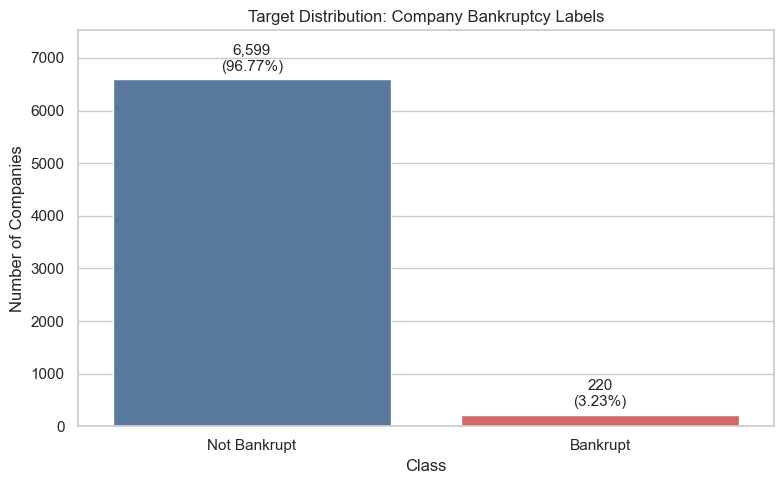

In [3]:
# Section 3: class imbalance and target distribution analysis

# Compute class counts and proportions for annotation.
target_counts = df["Bankrupt?"].value_counts().sort_index()
target_props = df["Bankrupt?"].value_counts(normalize=True).sort_index()
label_map = {0: "Not Bankrupt", 1: "Bankrupt"}
plot_labels = [label_map[idx] for idx in target_counts.index]

# Create a bar chart that makes the class imbalance visually obvious.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=plot_labels, y=target_counts.values, palette=["#4C78A8", "#E45756"], ax=ax)

# Add some extra headroom so the bar annotations do not crowd the title.
ax.set_ylim(0, target_counts.max() * 1.14)

# Add exact counts and percentages above each bar for easier interpretation.
for i, (count, prop) in enumerate(zip(target_counts.values, target_props.values)):
    ax.text(i, count + target_counts.max() * 0.015, f"{count:,}\n({prop:.2%})", ha="center", va="bottom", fontsize=11)

ax.set_title("Target Distribution: Company Bankruptcy Labels")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Companies")
plt.tight_layout()
plt.show()

### Section 3 analysis and interpretation
The plot makes the imbalance visually undeniable: 6,599 companies are labelled as not bankrupt and only 220 are labelled as bankrupt. That means the minority class represents about 3.23% of the dataset.

This confirms that plain accuracy would be misleading here. A trivial majority-class model would already appear to perform well, even while failing to identify distressed firms. That is why later sections will focus on precision-recall behaviour, recall, balanced accuracy, and threshold trade-offs rather than relying on raw accuracy alone.

## Section 4. Summary Statistics, Extreme Scales, and Skewness Audit

### What this section does
This section quantifies how uneven the predictor scales are and how heavy-tailed the feature distributions appear. We already know the dataset is numeric and imbalanced, but we still need to understand whether the predictors contain extreme-value behaviour that could destabilize some models.

### Why this matters
If many columns contain very large maxima or strong skewness, then a naive preprocessing strategy can distort the learning problem. In particular, rare but extreme values can dominate scale-sensitive models, while deleting rows may be dangerous because the bankrupt class is already very small.

### What to verify from the output
After running the next cell, we want to confirm:
- how many features have extremely large maxima,
- which columns are the strongest examples of scale inflation,
- how many predictors are strongly skewed,
- and whether winsorization plus selective scaling still looks like the right direction.

In [4]:
# Section 4: summary statistics, extreme scales, and skewness audit

# Build a descriptive summary table for all columns.
descriptive_summary = df.describe().T
print("Full descriptive summary table:")
display(descriptive_summary)

# Exclude the target before auditing predictor scale and skewness.
predictor_df = df.drop(columns=["Bankrupt?"])

# Detect features with very large maxima, which often indicate severe scale inflation.
large_max_threshold = 1e9
large_max_series = predictor_df.max().sort_values(ascending=False)
large_max_features = large_max_series[large_max_series > large_max_threshold]
print(f"Number of predictor columns with max > {large_max_threshold:.0e}: {len(large_max_features)}")
print("\nTop extreme-scale features by maximum value:")
display(large_max_features.head(15).to_frame(name="max_value"))

# Check whether these extreme values are rare accidents or common enough to matter.
large_value_frequency = pd.DataFrame(
    {
        "max_value": large_max_features,
        "n_rows_ge_1e9": [(predictor_df[col] >= large_max_threshold).sum() for col in large_max_features.index],
    }
)
large_value_frequency["pct_rows_ge_1e9"] = large_value_frequency["n_rows_ge_1e9"] / len(predictor_df)
print("Frequency of values >= 1e9 for the most extreme-scale features:")
display(large_value_frequency.head(15))

# Compute absolute skewness to understand how asymmetric the feature distributions are.
absolute_skew = predictor_df.skew().abs().sort_values(ascending=False)
skew_summary = pd.DataFrame(
    {
        "absolute_skew": absolute_skew,
        "exceeds_1": absolute_skew > 1,
        "exceeds_3": absolute_skew > 3,
    }
)

print("Top 20 predictors by absolute skewness:")
display(skew_summary.head(20))
print(f"\nPredictors with |skew| > 1: {(absolute_skew > 1).sum()} / {len(absolute_skew)}")
print(f"Predictors with |skew| > 3: {(absolute_skew > 3).sum()} / {len(absolute_skew)}")

Full descriptive summary table:


,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


Number of predictor columns with max > 1e+09: 23

Top extreme-scale features by maximum value:


,max_value
Current Asset Turnover Rate,1.000000e+10
Cash Turnover Rate,1.000000e+10
Quick Asset Turnover Rate,1.000000e+10
Fixed Assets Turnover Frequency,9.990000e+09
Operating Expense Rate,9.990000e+09
Total Asset Growth Rate,9.990000e+09
Inventory Turnover Rate (times),9.990000e+09
Research and development expense rate,9.980000e+09
Total debt/Total net worth,9.940000e+09
Inventory/Current Liability,9.910000e+09


Frequency of values >= 1e9 for the most extreme-scale features:


,max_value,n_rows_ge_1e9,pct_rows_ge_1e9
Current Asset Turnover Rate,1.000000e+10,1096,0.160727
Cash Turnover Rate,1.000000e+10,3453,0.506379
Quick Asset Turnover Rate,1.000000e+10,2156,0.316175
Fixed Assets Turnover Frequency,9.990000e+09,1067,0.156475
Operating Expense Rate,9.990000e+09,2057,0.301657
Total Asset Growth Rate,9.990000e+09,5438,0.797478
Inventory Turnover Rate (times),9.990000e+09,2275,0.333627
Research and development expense rate,9.980000e+09,2983,0.437454
Total debt/Total net worth,9.940000e+09,6,0.000880
Inventory/Current Liability,9.910000e+09,71,0.010412


Top 20 predictors by absolute skewness:


,absolute_skew,exceeds_1,exceeds_3
Fixed Assets to Assets,82.577237,True,True
Current Ratio,82.577237,True,True
Total income/Total expense,82.332424,True,True
Net Value Growth Rate,80.291844,True,True
Contingent liabilities/Net worth,79.670620,True,True
Realized Sales Gross Profit Growth Rate,77.925109,True,True
Operating Profit Growth Rate,71.688950,True,True
Operating Profit Rate,70.237164,True,True
Continuous Net Profit Growth Rate,67.097534,True,True
Total Asset Return Growth Rate Ratio,62.499961,True,True



Predictors with |skew| > 1: 81 / 95
Predictors with |skew| > 3: 68 / 95


### Section 4 analysis and interpretation
The output confirms that this dataset is not merely imbalanced in the target; it is also highly irregular in predictor scale. We found 23 predictor columns with maxima above `1e9`, and the new frequency table shows that some of these values occur in a large fraction of rows rather than as isolated accidents. For example, `Cash Turnover Rate` exceeds `1e9` in over half the dataset, and `Total Asset Growth Rate` does so in nearly 80% of rows.

That finding matters because it tells us these columns are not simple one-row anomalies that can be safely dropped away. Instead, they behave more like saturated or heavily distorted measurement scales, which supports capping their tails rather than deleting observations.

The skewness results reinforce the same conclusion. With 81 of 95 predictors above absolute skewness 1 and 68 above 3, the feature space is strongly asymmetric. This makes winsorization plus selective scaling a much safer plan than row deletion, especially because the bankrupt class is already tiny.

## Section 5. Target Correlation and Multicollinearity Inspection

### What this section does
This section looks for two different things: which variables move most strongly with the bankruptcy target, and which groups of variables are almost redundant with one another.

### Why this matters
Target correlation is not a complete modelling strategy, but it is a useful way to identify candidate predictors with strong linear signal. Multicollinearity matters because some financial-ratio families may carry nearly the same information, which affects how we interpret linear models and why tree-based models may behave differently.

### What to verify from the output
After the next figure, we want to see whether the strongest signals line up with financial intuition such as profitability, leverage, and borrowing dependency. After the heatmap, we want to confirm whether some ratio families cluster tightly enough to create redundancy.

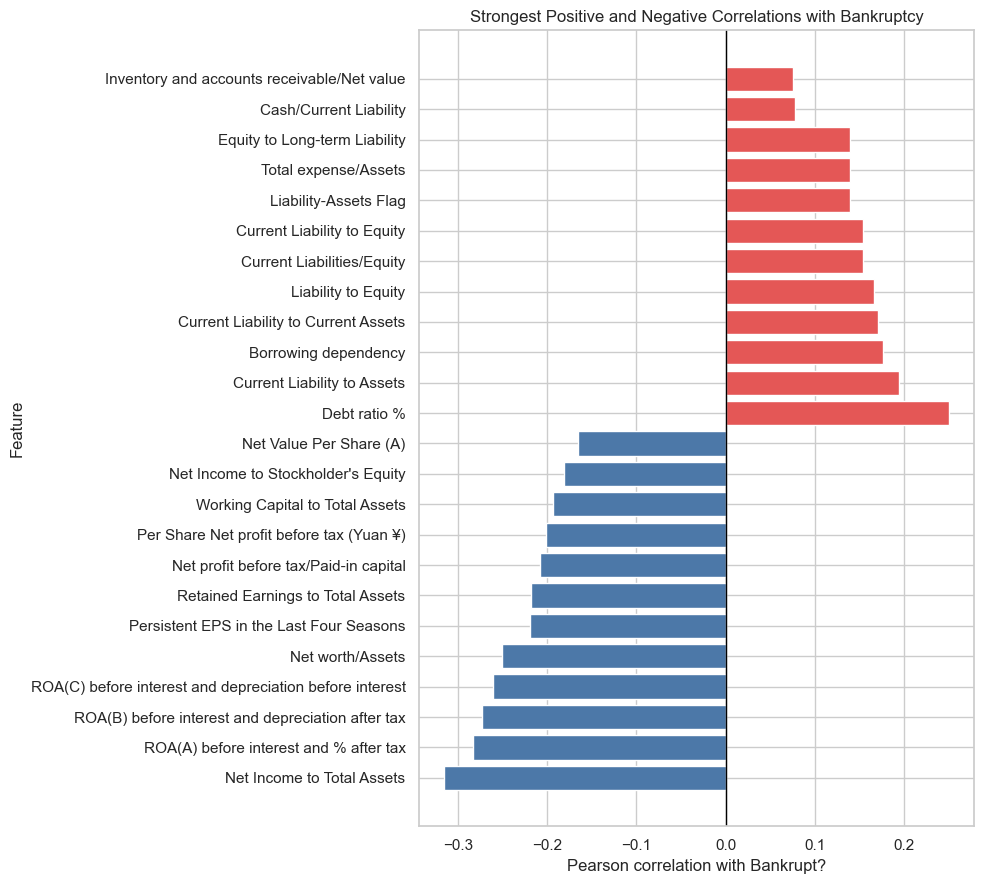

In [5]:
# Section 5A: correlation of predictors with the bankruptcy target

# Compute correlations with the target and remove the target itself from the series.
corr_with_target = df.corr(numeric_only=True)["Bankrupt?"].drop("Bankrupt?")

# Select the strongest negative and positive target correlations for visualization.
strongest_negative = corr_with_target.sort_values().head(12)
strongest_positive = corr_with_target.sort_values(ascending=False).head(12)
combined_target_corr = pd.concat([strongest_negative, strongest_positive])

# Plot the strongest target correlations in a single horizontal chart.
fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#4C78A8" if value < 0 else "#E45756" for value in combined_target_corr.values]
ax.barh(combined_target_corr.index, combined_target_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Strongest Positive and Negative Correlations with Bankruptcy")
ax.set_xlabel("Pearson correlation with Bankrupt?")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Section 5A analysis and interpretation
The strongest negative correlations with bankruptcy are concentrated in profitability and financial-strength variables such as `Net Income to Total Assets`, the three `ROA` variants, `Net worth/Assets`, `Persistent EPS`, and `Retained Earnings to Total Assets`. This matches economic intuition: firms with stronger profitability and stronger retained financial capacity are less likely to fail.

The strongest positive correlations are concentrated in leverage and liability pressure, especially `Debt ratio %`, `Current Liability to Assets`, `Borrowing dependency`, and other liability-to-equity style measures. That again fits the bankruptcy story we would expect.

These are only univariate correlations, so they do not tell us everything about the final model. But they do show that the dataset carries meaningful signal in directions that make financial sense.

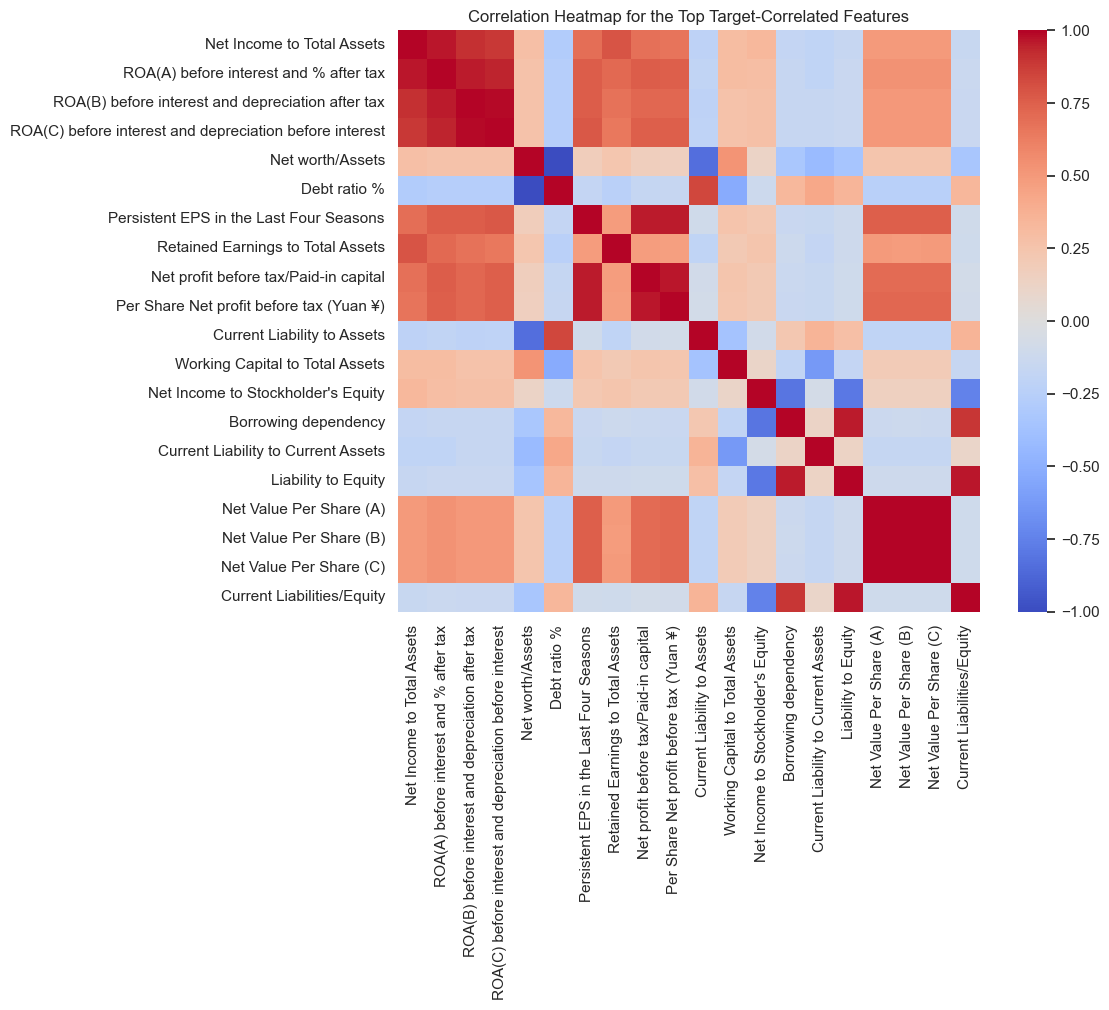

In [6]:
# Section 5B: multicollinearity inspection among the strongest target-correlated features

# Select the features with the largest absolute correlation to the target.
top_corr_features = corr_with_target.abs().sort_values(ascending=False).head(20).index.tolist()
correlation_matrix = df[top_corr_features].corr()

# Plot a heatmap to reveal tight correlation clusters and redundant feature families.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap for the Top Target-Correlated Features")
plt.tight_layout()
plt.show()

### Section 5B analysis and interpretation
The heatmap confirms that the strongest target-correlated features are not independent from one another. The `ROA(A)`, `ROA(B)`, `ROA(C)`, and related profitability variables form a tight positive cluster, which means they are capturing closely related financial information. The `Net Value Per Share` variants also appear almost interchangeable.

On the liability side, `Liability to Equity`, `Current Liabilities/Equity`, `Current Liability to Current Assets`, and related measures also cluster together. This tells us that linear models may face interpretability challenges under multicollinearity, while tree-based models are more naturally tolerant of redundant predictor groups.

This does not mean we should delete correlated features blindly. It means we should regularize and interpret carefully, and we should expect different model families to exploit these clusters differently.

## Section 6. Distribution and Outlier Comparison for Key Predictors

### What this section does
This section moves from summary statistics to feature-level visual inspection. We will compare the class-specific distributions of the strongest predictors and then inspect their tails through boxplots.

### Why this matters
A feature can show useful correlation with the target and still be difficult to model if its distribution is extremely heavy-tailed or if the class overlap is too strong. These visual checks help us see whether class separation exists in practice and whether the tails are severe enough to justify capping instead of row deletion.

### What to verify from the output
After the KDE figure, we want to see whether the bankrupt and non-bankrupt distributions separate at least partially for the strongest predictors. After the boxplots, we want to confirm that the tails are substantial enough that winsorization is a better choice than dropping rows from an already rare positive class.

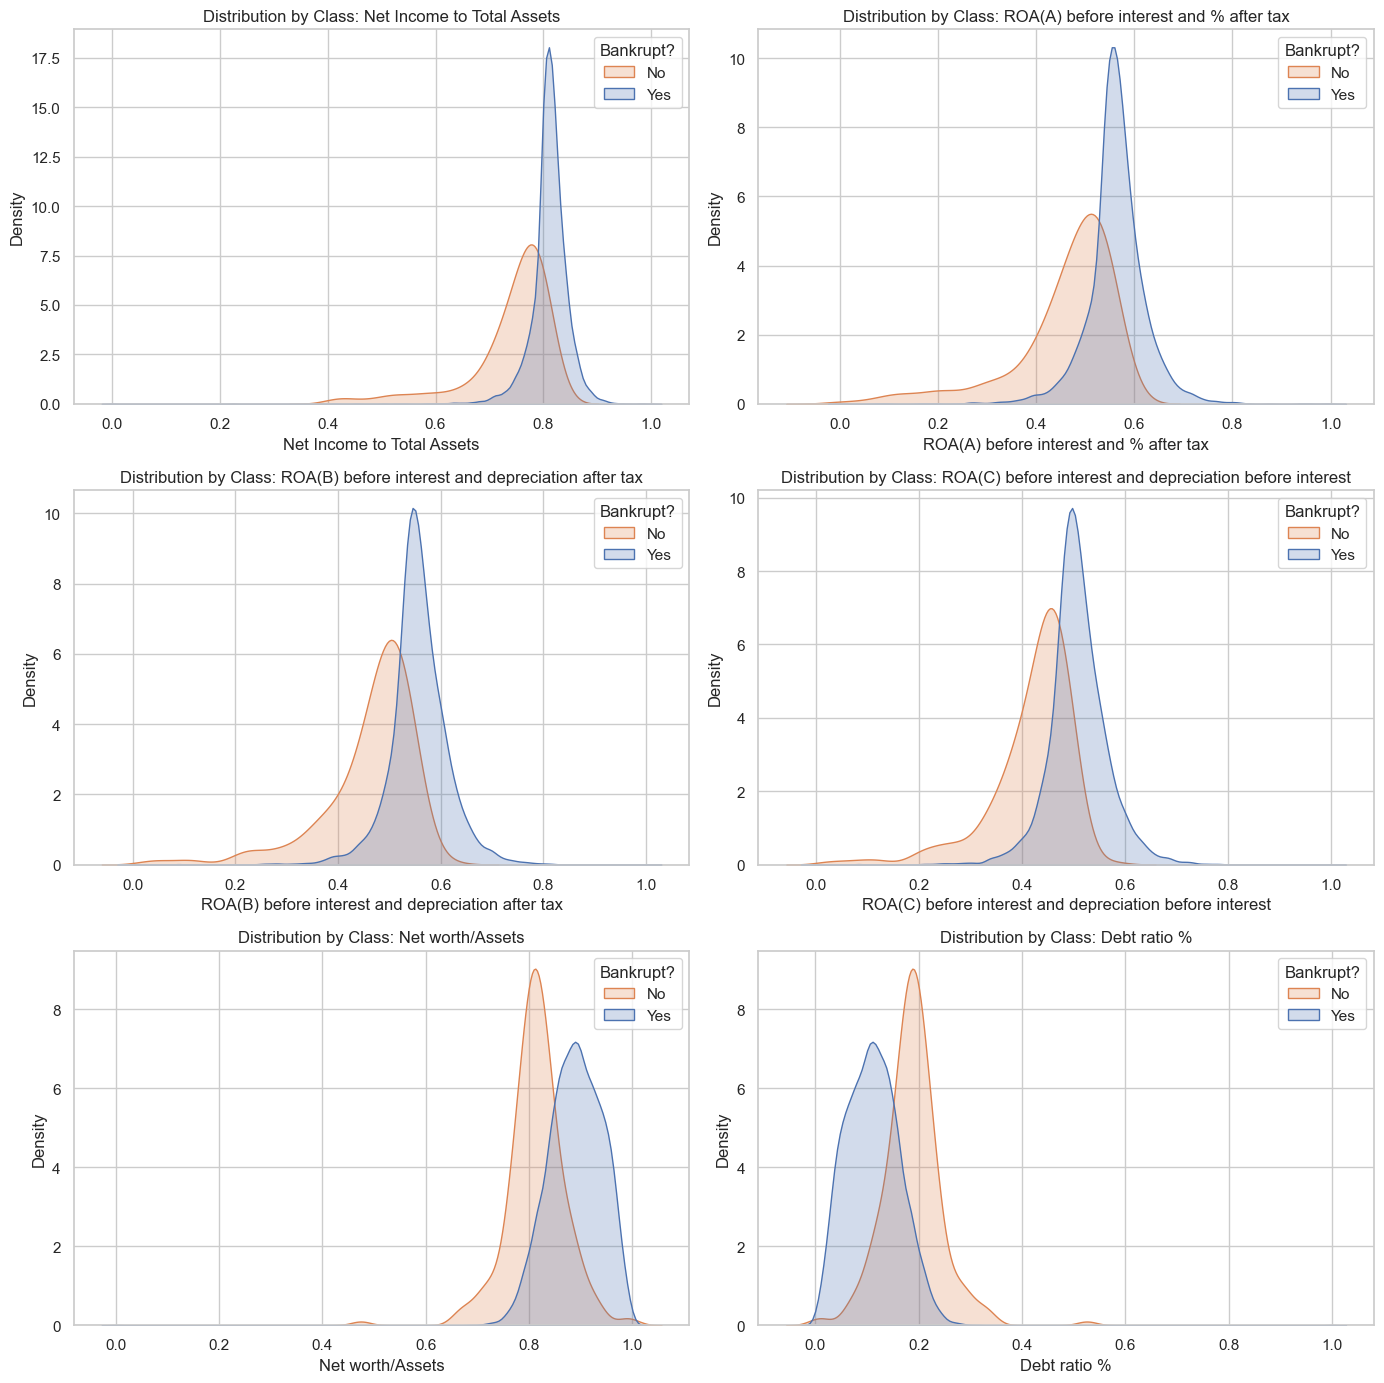

In [7]:
# Section 6A: KDE comparison for the six strongest target-correlated predictors

# Select the top six predictors by absolute correlation with the target.
top_six_features = corr_with_target.abs().sort_values(ascending=False).head(6).index.tolist()

# Plot class-specific KDE curves to inspect separation between bankrupt and non-bankrupt firms.
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, feature in zip(axes, top_six_features):
    sns.kdeplot(data=df, x=feature, hue="Bankrupt?", common_norm=False, fill=True, alpha=0.25, ax=ax)
    ax.set_title(f"Distribution by Class: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend(title="Bankrupt?", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

### Section 6A analysis and interpretation
These KDE plots show real class separation for the strongest predictors. For `Net Income to Total Assets` and the `ROA` variables, the bankrupt-class distribution is shifted toward weaker profitability relative to the non-bankrupt class. For `Debt ratio %`, the direction reverses, with bankrupt firms concentrated at higher debt levels.

At the same time, the distributions still overlap. That is important because it means the problem is informative but not trivial: no single variable cleanly separates the two classes, which justifies using multivariate models rather than relying on one threshold on one feature.

The plots also hint that some distributions are sharply concentrated with noticeable tails, so the next step is to inspect outlier behaviour directly.

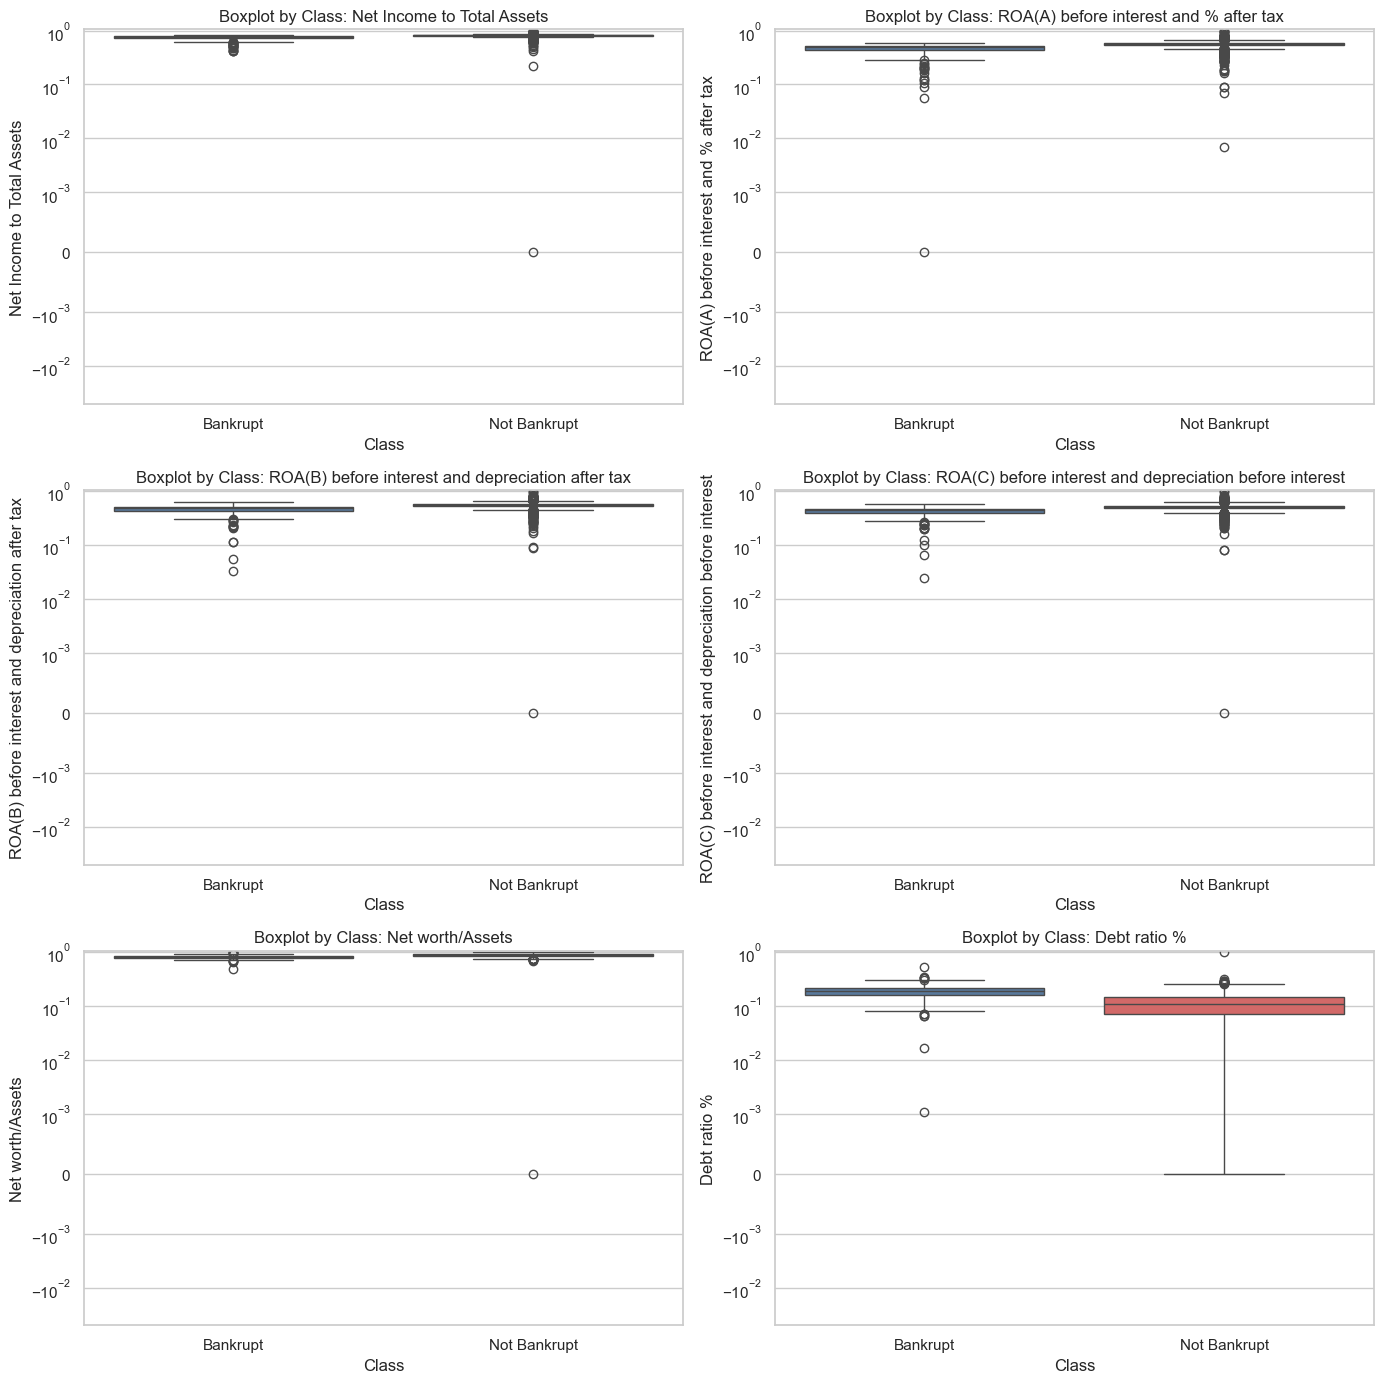

In [8]:
# Section 6B: boxplot comparison for the same six predictors

# Reshape the data so we can create consistent feature-wise boxplots by class.
plot_df = df[top_six_features + ["Bankrupt?"]].copy()
plot_df["Bankrupt?"] = plot_df["Bankrupt?"].map({0: "Not Bankrupt", 1: "Bankrupt"})

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, feature in zip(axes, top_six_features):
    sns.boxplot(data=plot_df, x="Bankrupt?", y=feature, ax=ax, palette=["#4C78A8", "#E45756"])
    ax.set_title(f"Boxplot by Class: {feature}")
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)

    # Use a symmetric log scale to compress tails safely even when values approach zero.
    ax.set_yscale("symlog", linthresh=1e-3)

plt.tight_layout()
plt.show()

### Section 6B analysis and interpretation
The boxplots confirm that the strongest predictors contain noticeable tail behaviour and outlying observations in both classes. The class medians still differ in meaningful directions, especially for profitability and debt variables, but the tails make it clear that extreme values are part of the data structure.

That is exactly why we prefer winsorization over row deletion. If we removed rows aggressively, we would risk throwing away rare but informative bankrupt examples. Capping the tails is a safer compromise: it reduces the influence of extreme values while preserving every observation for a dataset with only 220 positives.

## Section 7. Constant-Feature Removal and Feature Group Definition

### What this section does
Now that the exploratory analysis is complete, we can make the first structural modelling change: removing the verified constant feature and defining the predictor groups that will feed the preprocessing pipeline.

### Why this matters
This is the last purely structural step before we build transformations. We want to separate continuous ratio features from the one meaningful binary flag because they should not be preprocessed in the same way.

### What to verify from the output
After the next code cell, we should confirm that:
- `Net Income Flag` has been removed,
- the target is separated cleanly from the predictors,
- the remaining predictor count is 94,
- and `Liability-Assets Flag` is isolated as the only binary feature that should later bypass scaling.

In [9]:
# Section 7: remove the constant feature and define feature groups

# Remove the verified constant feature before modelling.
df_model = df.drop(columns=["Net Income Flag"]).copy()

# Separate predictors and target for all later modelling steps.
X = df_model.drop(columns=["Bankrupt?"]).copy()
y = df_model["Bankrupt?"].copy()

# Define the one binary feature and the remaining numeric ratio features.
binary_cols = ["Liability-Assets Flag"]
numeric_cols = [column for column in X.columns if column not in binary_cols]

print("Shape after dropping Net Income Flag:", df_model.shape)
print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nBinary feature columns:", binary_cols)
print("Number of numeric ratio features:", len(numeric_cols))
print("Total predictors:", len(binary_cols) + len(numeric_cols))

Shape after dropping Net Income Flag: (6819, 95)
Predictor matrix shape: (6819, 94)
Target vector shape: (6819,)

Binary feature columns: ['Liability-Assets Flag']
Number of numeric ratio features: 93
Total predictors: 94


### Section 7 analysis and interpretation
The structural modelling dataset now looks exactly as intended. After removing `Net Income Flag`, we are left with 94 predictors: 93 continuous financial-ratio features and 1 binary indicator, `Liability-Assets Flag`.

This separation is important because the numeric ratios need tail control and scaling, while the binary flag should be passed through without continuous rescaling. The output confirms that our later preprocessing design can be built on a clean and correctly partitioned feature set.

## Section 8. Custom Winsorizer Validation and Preprocessing Pipeline Checks

### What this section does
This section defines the custom transformer that will cap extreme values and then verifies that the planned preprocessing block behaves correctly on both synthetic and real data.

### Why this matters
A preprocessing pipeline should not be trusted just because it compiles. We want to verify two things explicitly before model training starts: first, that the winsorizer clips values at the intended quantile boundaries, and second, that the binary indicator survives the transformation unchanged.

### What to verify from the output
After the next cell, we should confirm that:
- the winsorizer clips synthetic extremes in the expected direction,
- the preprocessing block can fit and transform a small sample successfully,
- and the binary flag emerges unchanged in the transformed output.

In [10]:
# Section 8: define and validate the custom winsorizer and preprocessing block

# Import the base classes needed to build custom and column-wise preprocessing.
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


class Winsorizer(BaseEstimator, TransformerMixin):
    """Cap each numeric feature at fixed lower and upper quantiles learned from training data."""

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # Learn the clipping thresholds from the data provided to fit.
        X_df = pd.DataFrame(X)
        self.low_ = X_df.quantile(self.lower)
        self.high_ = X_df.quantile(self.upper)
        return self

    def transform(self, X):
        # Clip each column independently using the thresholds learned in fit.
        X_df = pd.DataFrame(X).copy()
        return X_df.clip(lower=self.low_, upper=self.high_, axis=1).to_numpy()


# Unit-test the winsorizer on a simple synthetic sequence.
synthetic_train = pd.DataFrame({"x": np.arange(1, 101)})
synthetic_test = pd.DataFrame({"x": [0, 200]})

winsorizer_test = Winsorizer(lower=0.01, upper=0.99)
winsorizer_test.fit(synthetic_train)
clipped_values = winsorizer_test.transform(synthetic_test)

print("Synthetic winsorizer test output:")
print(clipped_values.ravel())

# Build the preprocessing block that will be reused by later models.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("winsor", Winsorizer()), ("scaler", StandardScaler())]), numeric_cols),
        ("binary", "passthrough", binary_cols),
    ]
)

# Run a small smoke test on a subset of the real data.
smoke_sample = X.head(8).copy()
transformed_smoke = preprocessor.fit_transform(smoke_sample)
print("\nSmoke-test transformed shape:", transformed_smoke.shape)

# Verify that the binary column is preserved in the last transformed column.
original_binary = smoke_sample[binary_cols[0]].to_numpy()
transformed_binary = transformed_smoke[:, -1]
print("Binary column preserved exactly:", np.array_equal(original_binary, transformed_binary))

Synthetic winsorizer test output:
[ 1.99 99.01]

Smoke-test transformed shape: (8, 94)
Binary column preserved exactly: True


### Section 8 analysis and interpretation
The validation checks confirm that the preprocessing design behaves as intended before we rely on it in model training. The synthetic test returned clipped values of `1.99` and `99.01`, which is exactly the expected behaviour for 1st and 99th percentile capping on the sequence from 1 to 100.

The smoke test on real data also succeeded: the transformed sample has the expected 94 output columns, and the binary flag remained unchanged. That gives us confidence that the preprocessing block is structurally correct and ready to be used inside leakage-safe modelling pipelines.

### Presenter note — how to explain this section in one breath
**Winsorization in plain English:** some columns have a few crazy-large values that would dominate a scaled model. Instead of deleting those rows (we only have 220 bankrupt firms, we cannot afford to lose any), we **cap** each column at its 1st and 99th percentile. The custom `Winsorizer` class just learns those caps on the training fold and clips on transform. The unit test on `1..100` returns `1.99` and `99.01`, which is exactly what 1st/99th percentile capping should produce.

**Why we built it from scratch:** scikit-learn does not ship a column-wise winsorizer that learns its thresholds during `fit`, so we wrote a 10-line transformer that follows the `BaseEstimator / TransformerMixin` contract. This lets us drop it into a `ColumnTransformer` and inside a CV loop without leaking percentiles from the test set.

## Section 9. Stratified Train/Test Split and Leakage-Control Notes

### What this section does
This section creates the single held-out test set that will remain untouched until final evaluation. It is the boundary that prevents information leakage from the modelling workflow back into evaluation.

### Why this matters
Any learned preprocessing step fitted on the full dataset would leak test-set information into the training process. That is why we split now, before fitting winsorization thresholds, scalers, feature selectors, resampling procedures, or models.

### What to verify from the output
After the split, we want to confirm that:
- the train and test sizes look correct,
- the class proportions remain close to the original 3.23%,
- and the test set contains the expected small number of positive cases, which justifies relying primarily on repeated cross-validation later.

In [11]:
# Section 9: create the stratified holdout split

# Import the splitting utility only now, right before creating the holdout set.
from sklearn.model_selection import train_test_split

# Create a leakage-safe stratified split so the class balance is preserved.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Summarize train and test sizes and class proportions.
train_class_counts = y_train.value_counts().sort_index()
test_class_counts = y_test.value_counts().sort_index()
train_class_props = y_train.value_counts(normalize=True).sort_index()
test_class_props = y_test.value_counts(normalize=True).sort_index()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class counts:")
print(train_class_counts)
print("\nTraining class proportions:")
print(train_class_props)
print("\nTest class counts:")
print(test_class_counts)
print("\nTest class proportions:")
print(test_class_props)

Training shape: (5455, 94)
Test shape: (1364, 94)

Training class counts:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

Training class proportions:
Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64

Test class counts:
Bankrupt?
0    1320
1      44
Name: count, dtype: int64

Test class proportions:
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


### Section 9 analysis and interpretation
The stratified split preserved the class balance almost perfectly. The training set contains 176 bankrupt firms out of 5,455 rows, and the test set contains 44 bankrupt firms out of 1,364 rows, which is exactly in line with the overall 3.23% base rate.

This output validates two important design choices. First, the split itself is correct and leakage-safe. Second, the test set is too small in positive cases to be treated as the only source of truth for model quality, which is why repeated stratified cross-validation on the training data will remain our primary evaluation protocol.

### Presenter note — what "leakage-safe" actually means here
If we had fit the winsorizer, scaler, or SMOTE on the full dataset *before* splitting, the model would have indirectly seen the test set during training. The test scores would then look better than they really are, and the project would not be defensible.

**One-line answer if asked:** "We split first, then every learned step — capping, scaling, feature selection, SMOTE — is fit only on training folds, never on test data."

**Why stratified:** the positive class is only 3.23%. A random split could accidentally put very few bankrupt firms in the test set. `stratify=y` forces both halves to keep the same class ratio, which is why we end up with exactly 44 bankrupt firms in the test set (about 3.23% of 1,364).

## Section 10. Imbalance Strategy Design and Fold-Safe Resampling Setup

### Why this section is markdown-only
This section explains the imbalance strategy conceptually before we code it into model-specific pipelines. The goal is to make the reasoning explicit, because the correctness of the imbalance strategy depends more on where it is applied than on simply calling a resampling function.

### 10.1 Algorithm-level weighting
Some models can absorb class imbalance directly through weighted loss functions. In this notebook, Logistic Regression, Random Forest, and HistGradientBoosting will use class weighting, while XGBoost will use `scale_pos_weight` rather than synthetic oversampling.

### 10.2 Fold-safe SMOTE
SMOTE is useful, but only when it is applied inside each training fold of cross-validation. If it is applied to the full dataset before splitting, synthetic minority samples can leak information into the test set or validation folds and produce misleadingly optimistic scores.

### 10.3 What this means for our notebook
We will not oversample `X_train` globally and we will never touch `X_test` with SMOTE. Instead, SMOTE will appear only inside `imblearn` pipelines for the models where data-level resampling is appropriate. This keeps the workflow scientifically fair and consistent with the project guidelines.

### Presenter note — SMOTE in one minute
**What SMOTE does:** it generates *synthetic* minority-class rows by interpolating between real bankrupt firms and their nearest neighbours. This pushes the class ratio toward balance so models do not just predict "not bankrupt" for everyone.

**The trap we are avoiding:** if SMOTE is applied to the whole training set once and then 5-fold CV is run, the synthetic neighbours of a real point may end up in a different fold than that real point. The model essentially gets to "see" near-copies of validation points during training. That is leakage, and it is exactly how some Kaggle notebooks reach 99% F1 dishonestly.

**Our fix:** SMOTE lives *inside* an `imblearn.Pipeline`, so for every CV fold the resampling is re-run only on that fold's training portion. No synthetic points ever cross a fold boundary.

**One-line answer if asked:** "Our SMOTE is inside the pipeline, so it is refit on every fold and never touches validation or test data."

## Section 11. Baseline Cross-Validation Harness and Metric Definition

### What this section does
This section defines the reusable evaluation function that will score every candidate model under the same repeated stratified cross-validation protocol.

### Why this matters
A fair comparison requires the same split logic and the same metrics across all candidate models. Because the holdout contains only 44 positives, repeated stratified cross-validation on the training set is our main performance estimate rather than a single split score.

### What to verify from the output
After the next cell, we want to confirm that:
- the repeated cross-validation object is configured as intended,
- the scoring dictionary contains the metrics we care about,
- and the helper function is ready to evaluate all candidate models consistently.

In [12]:
# Section 11: define the shared repeated cross-validation harness

# Import the model-evaluation tools needed for fair repeated validation.
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

# Define the repeated stratified cross-validation object used for baseline comparisons.
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

# Define the shared metric dictionary so every model is scored under identical criteria.
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "balanced_accuracy": "balanced_accuracy",
}


def evaluate_cv(pipeline, X_data, y_data, model_name, cv_object=repeated_cv, scoring_dict=scoring):
    """Run repeated stratified CV and return mean/std metrics in a one-row DataFrame."""

    cv_output = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv_object,
        scoring=scoring_dict,
        n_jobs=-1,
        return_train_score=False,
    )

    result_row = {"model": model_name}
    for metric_name in scoring_dict:
        metric_values = cv_output[f"test_{metric_name}"]
        result_row[f"{metric_name}_mean"] = metric_values.mean()
        result_row[f"{metric_name}_std"] = metric_values.std()

    return pd.DataFrame([result_row])


print("Repeated CV configuration:", repeated_cv)
print("\nMetrics used for model comparison:")
print(list(scoring.keys()))

Repeated CV configuration: RepeatedStratifiedKFold(n_repeats=5, n_splits=5, random_state=42)

Metrics used for model comparison:
['average_precision', 'roc_auc', 'f1', 'recall', 'precision', 'balanced_accuracy']


### Section 11 analysis and interpretation
The evaluation harness is now fixed and consistent. Every candidate model will be scored under the same repeated stratified 5-by-5 protocol and the same metric set, which means later comparisons will be methodologically fair rather than dependent on changing splits or changing metrics.

This is especially important here because the holdout test set contains only 44 bankrupt firms. Repeated cross-validation on the training set gives us a much more stable view of baseline model behaviour before we trust any single test-set result.

### Presenter note — why repeated CV and not just one split
The test set has only 44 bankrupt firms. A single train/validation split could swing a model's measured PR-AUC by several points just by which firms happen to land where. That is statistical noise, not a real performance difference.

**`RepeatedStratifiedKFold(n_splits=5, n_repeats=5)` means:** 5-fold cross-validation, repeated 5 times with different shuffles. That gives us **25 validation scores per model**, which we average to get a stable estimate.

**Why PR-AUC (`average_precision`) is the primary metric:** ROC-AUC is dominated by the huge number of true negatives and stays optimistic even when the model is bad at the rare class. PR-AUC focuses only on how well we rank the **bankrupt** firms, which is what actually matters in this business.

**One-line answer if asked:** "We score every model on 25 stratified folds with PR-AUC because the positive class is rare and we want a stable, minority-aware estimate."

### Workflow diagram — what the whole pipeline looks like at a glance
The next cell draws a simple block diagram of the leakage-safe workflow we just finished setting up. Use this as the visual anchor for the entire project. Everything before it was preparation; everything after it is modelling on top of this exact structure.

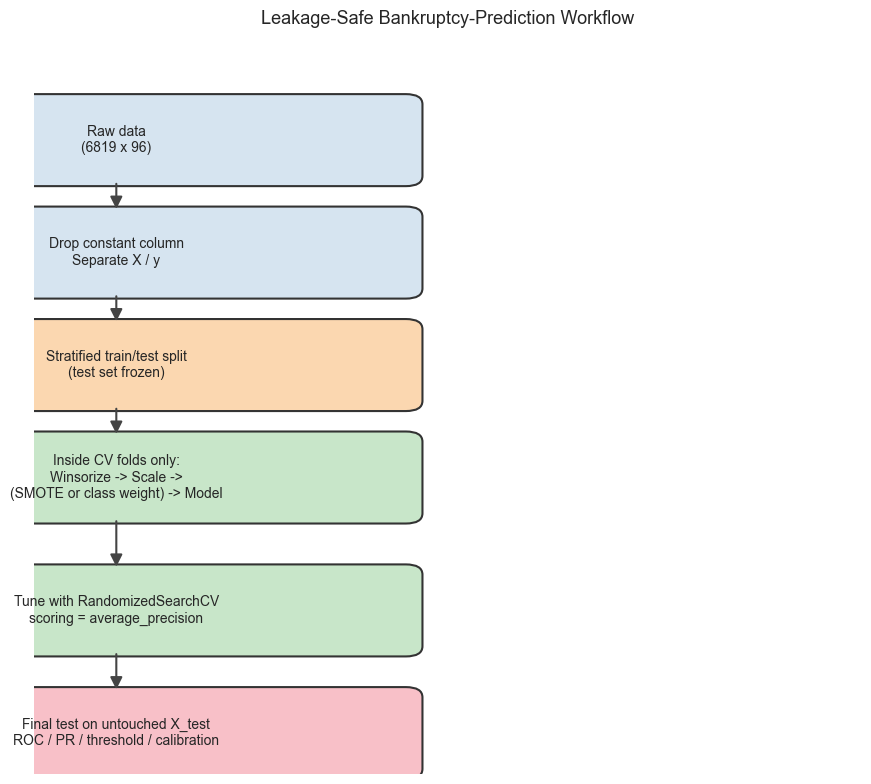

In [13]:
# Presentation visual: leakage-safe workflow diagram (self-contained, no upstream data needed).
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Define each block as (x, y, text, facecolor).
diagram_blocks = [
    (0.5, 6.2, "Raw data\n(6819 x 96)", "#D6E4F0"),
    (0.5, 5.1, "Drop constant column\nSeparate X / y", "#D6E4F0"),
    (0.5, 4.0, "Stratified train/test split\n(test set frozen)", "#FBD7B0"),
    (0.5, 2.9, "Inside CV folds only:\nWinsorize -> Scale ->\n(SMOTE or class weight) -> Model", "#C8E6C9"),
    (0.5, 1.6, "Tune with RandomizedSearchCV\nscoring = average_precision", "#C8E6C9"),
    (0.5, 0.4, "Final test on untouched X_test\nROC / PR / threshold / calibration", "#F8C0C8"),
]

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_xlim(0, 5)
ax.set_ylim(0, 7.2)
ax.axis("off")

# Draw each block as a rounded rectangle with centered text.
for x_center, y_center, text, color in diagram_blocks:
    box = FancyBboxPatch(
        (x_center - 1.8, y_center - 0.4),
        3.6,
        0.8,
        boxstyle="round,pad=0.05,rounding_size=0.1",
        linewidth=1.5,
        edgecolor="#333333",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x_center, y_center, text, ha="center", va="center", fontsize=10)

# Draw downward arrows between consecutive blocks.
for i in range(len(diagram_blocks) - 1):
    upper_y = diagram_blocks[i][1] - 0.4
    lower_y = diagram_blocks[i + 1][1] + 0.4
    arrow = FancyArrowPatch(
        (0.5, upper_y),
        (0.5, lower_y),
        arrowstyle="-|>",
        mutation_scale=18,
        color="#444444",
        linewidth=1.5,
    )
    ax.add_patch(arrow)

ax.set_title("Leakage-Safe Bankruptcy-Prediction Workflow", fontsize=13, pad=10)
plt.tight_layout()
plt.show()

## Section 12. Logistic Regression Pipeline and Baseline Results

### What this section does
We start modelling with a linear baseline that is easy to interpret. This model combines the leakage-safe preprocessing block, univariate feature selection, fold-safe SMOTE, and class-weighted logistic regression.

### Why this matters
A strong project needs at least one model whose behaviour is explainable in simple statistical terms. Logistic Regression gives us that anchor: even if a more complex model wins later, the linear baseline tells us what performance is achievable with a transparent classifier.

### What to verify from the output
After the next cell, we want to know:
- whether the pipeline runs cleanly under repeated CV,
- whether recall is strong enough to make the model useful in an imbalanced setting,
- and how much precision the model sacrifices to recover more bankrupt firms.

In [14]:
# Section 12: build and evaluate the Logistic Regression baseline pipeline

# Import the modelling components needed for the linear baseline.
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression


# Define a helper that returns a fresh preprocessing block for each model family.
def make_preprocessor(scale_numeric=True):
    numeric_steps = [("winsor", Winsorizer())]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric_cols),
            ("binary", "passthrough", binary_cols),
        ]
    )


# Build the leakage-safe Logistic Regression pipeline.
logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", make_preprocessor(scale_numeric=True)),
        ("select", SelectKBest(score_func=f_classif, k=30)),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Evaluate the linear baseline on the training set only under repeated CV.
logistic_cv_result = evaluate_cv(logistic_pipeline, X_train, y_train, "Logistic Regression")
display(logistic_cv_result)

,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,Logistic Regression,0.393212,0.077541,0.929455,0.020326,0.294864,0.024137,0.837333,0.071876,0.179166,0.015809,0.854431,0.034363


### Section 12 analysis and interpretation
The Logistic Regression baseline behaves the way a useful imbalanced-data baseline often does: it recovers a large share of bankrupt firms, with mean recall around `0.84`, but it pays for that with low precision, around `0.18`.

Its PR-AUC is materially above the positive base rate, so it is learning meaningful signal rather than guessing. At the same time, the low precision shows that a purely linear boundary will generate many false positives. That makes this a strong interpretability baseline, but not yet an obvious final model.

## Section 13. Random Forest Pipeline and Baseline Results

### What this section does
This section evaluates a bagged tree ensemble that can capture non-linear interactions and complex variable interactions more naturally than a linear classifier.

### Why this matters
The earlier EDA showed correlated profitability families, leverage families, and heavy tails. Random Forest is a useful next step because it can model non-linear structure without assuming a linear decision boundary.

### What to verify from the output
After the next cell, we want to see whether the forest improves PR-AUC or precision relative to Logistic Regression, and whether it still retains enough recall to remain useful in a risk-sensitive setting.

In [15]:
# Section 13: build and evaluate the Random Forest baseline pipeline

# Import the bagging-based tree ensemble.
from sklearn.ensemble import RandomForestClassifier

# Build the Random Forest pipeline using winsorization and fold-safe SMOTE.
random_forest_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", make_preprocessor(scale_numeric=False)),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced_subsample",
                n_estimators=300,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Evaluate the Random Forest baseline under the same repeated CV protocol.
random_forest_cv_result = evaluate_cv(random_forest_pipeline, X_train, y_train, "Random Forest")
display(random_forest_cv_result)

,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,Random Forest,0.362149,0.059591,0.936069,0.013414,0.405287,0.056709,0.454667,0.069022,0.368724,0.058145,0.714168,0.034324


### Section 13 analysis and interpretation
The Random Forest baseline is informative because it improves some aspects of classification quality but not all of them. Compared with Logistic Regression, it delivers much better precision and a stronger F1 score, but its PR-AUC is actually lower and its recall drops substantially.

That means the forest is being more selective and producing fewer false positives, but it is also missing more bankrupt firms. For a banking use case, that is not automatically better. This is the first case where the live output diverges from the earlier quick benchmark, so we should keep that in mind when we later decide whether the forest deserves aggressive tuning or whether a weighted variant would be worth reconsidering.

## Section 14. XGBoost Pipeline and Baseline Results

### What this section does
This section evaluates the first boosted-tree candidate, using class reweighting through `scale_pos_weight` instead of SMOTE.

### Why this matters
Boosted trees are often strong on structured tabular data, and our earlier audit suggested that this family may be especially competitive here. Using `scale_pos_weight` also gives us an imbalance-aware strategy that does not rely on synthetic resampling.

### What to verify from the output
After the next cell, we want to see whether XGBoost improves PR-AUC relative to both the linear baseline and the Random Forest, and whether it preserves enough recall to remain useful in a bankruptcy-detection context.

In [16]:
# Section 14: build and evaluate the XGBoost baseline pipeline

# Import the boosted-tree classifier.
from xgboost import XGBClassifier

# Compute the imbalance ratio for XGBoost's weighted loss.
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight_value = negative_count / positive_count

# Build the XGBoost pipeline using weighted loss instead of SMOTE.
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(scale_numeric=False)),
        (
            "model",
            XGBClassifier(
                scale_pos_weight=scale_pos_weight_value,
                n_estimators=400,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.8,
                reg_lambda=2.0,
                eval_metric="aucpr",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# Evaluate the boosted-tree baseline under the same repeated CV protocol.
xgboost_cv_result = evaluate_cv(xgboost_pipeline, X_train, y_train, "XGBoost")
display(xgboost_cv_result)

,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,XGBoost,0.412229,0.080801,0.930019,0.018858,0.449056,0.05059,0.525937,0.069008,0.395127,0.052284,0.749329,0.033896


### Section 14 analysis and interpretation
XGBoost is the strongest baseline so far by PR-AUC, which is encouraging because this is the family we expected to be highly competitive on structured financial data. It also achieves a more balanced trade-off between recall and precision than Logistic Regression: lower recall than the linear model, but substantially stronger precision and F1.

That profile is important in this project. It suggests that boosted trees may recover a meaningful share of bankrupt firms without exploding the false-positive rate. At this point, XGBoost looks like a serious candidate for the final tuned champion.

## Section 15. HistGradientBoosting Pipeline and Baseline Results

### What this section does
This section evaluates the sklearn-native boosting challenger. It uses histogram-based boosting with class weighting and no SMOTE.

### Why this matters
HistGradientBoosting is lighter-weight than XGBoost and keeps the project less dependent on external libraries, while still representing a strong boosted-tree alternative. Our earlier audit suggested it might be highly competitive on this dataset.

### What to verify from the output
After the next cell, we want to see whether the sklearn-native challenger can match or exceed XGBoost on PR-AUC and whether its performance is stable enough to justify full tuning.

In [17]:
# Section 15: build and evaluate the HistGradientBoosting baseline pipeline

# Import the sklearn-native boosted-tree challenger.
from sklearn.ensemble import HistGradientBoostingClassifier

# Build the HistGradientBoosting pipeline using weighted loss and no SMOTE.
hist_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(scale_numeric=False)),
        (
            "model",
            HistGradientBoostingClassifier(
                class_weight="balanced",
                max_iter=250,
                learning_rate=0.04,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Evaluate the sklearn-native boosting baseline under repeated CV.
hist_gb_cv_result = evaluate_cv(hist_gb_pipeline, X_train, y_train, "HistGradientBoosting")
display(hist_gb_cv_result)

,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,HistGradientBoosting,0.437472,0.075556,0.932658,0.018151,0.410871,0.065596,0.352032,0.067572,0.502538,0.08786,0.670087,0.033689


### Section 15 analysis and interpretation
HistGradientBoosting is now the strongest default model by PR-AUC, which validates the earlier audit that boosting is likely the most promising family for this dataset. Its precision is the strongest among the models tested so far, but its recall is noticeably lower than both Logistic Regression and XGBoost.

That means this model is highly selective: it makes fewer positive calls, but the ones it makes are more often correct. Whether that is preferable depends on how much we value bankrupt-firm recovery versus false-alarm control. This model clearly deserves full tuning because it is already the PR-AUC leader.

## Section 16. Tiny MLP Pipeline and Baseline Results

### What this section does
This section evaluates the tiny neural-network candidate allowed by the project rules. The model uses one hidden layer, scaled numeric inputs, and fold-safe SMOTE.

### Why this matters
The neural model is included to satisfy model-family diversity, not because this is a deep-learning project. Its value here is to test whether a small non-linear network can extract a useful decision boundary once the numeric predictors are stabilized.

### What to verify from the output
After the next cell, we want to see whether the tiny MLP converges stably and whether it adds useful performance diversity relative to the tree-based and linear baselines.

In [18]:
# Section 16: build and evaluate the tiny MLP baseline pipeline

# Import the small neural-network classifier.
from sklearn.neural_network import MLPClassifier

# Build the tiny neural-network pipeline with scaling and fold-safe SMOTE.
mlp_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", make_preprocessor(scale_numeric=True)),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(32,),
                activation="relu",
                solver="adam",
                max_iter=300,
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Evaluate the tiny neural baseline under the same repeated CV protocol.
mlp_cv_result = evaluate_cv(mlp_pipeline, X_train, y_train, "Tiny MLP")
display(mlp_cv_result)

,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,Tiny MLP,0.352941,0.068235,0.890356,0.027298,0.377919,0.058633,0.485238,0.100683,0.31406,0.049966,0.724718,0.048349


### Section 16 analysis and interpretation
The tiny MLP runs successfully and adds modelling diversity, but it is not leading the baseline race. Its recall is reasonable, yet both PR-AUC and ROC-AUC are weaker than the boosted-tree models and weaker than the Logistic Regression baseline on the primary metric.

That does not make the neural model useless. It still provides a valid non-linear benchmark within the project constraints. But based on the baseline outputs alone, it does not currently look like the most promising final champion.

## Section 17. Default Model Comparison Table and Interpretation

### What this section does
This section consolidates the baseline repeated-CV results into one table so we can compare the default candidates side by side.

### Why this matters
Single-model results are hard to interpret in isolation. A shared comparison table makes it clear which models are strongest on the primary metric, which ones maximize recall, and which ones may not deserve the same tuning budget.

### What to verify from the output
After the next cell, we want to identify:
- the default leader on PR-AUC,
- the strongest recall-oriented model,
- and any candidates that look weak enough to treat as secondary rather than central.

In [19]:
# Section 17: consolidate the default repeated-CV results into one comparison table

# Combine the baseline result rows for a side-by-side comparison.
default_cv_results = pd.concat(
    [
        logistic_cv_result,
        random_forest_cv_result,
        xgboost_cv_result,
        hist_gb_cv_result,
        mlp_cv_result,
    ],
    ignore_index=True,
)

# Sort primarily by average precision, then by recall as a secondary consideration.
default_cv_results_sorted = default_cv_results.sort_values(
    by=["average_precision_mean", "recall_mean"],
    ascending=[False, False],
).reset_index(drop=True)

display(default_cv_results_sorted)

,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,HistGradientBoosting,0.437472,0.075556,0.932658,0.018151,0.410871,0.065596,0.352032,0.067572,0.502538,0.087860,0.670087,0.033689
1,XGBoost,0.412229,0.080801,0.930019,0.018858,0.449056,0.050590,0.525937,0.069008,0.395127,0.052284,0.749329,0.033896
2,Logistic Regression,0.393212,0.077541,0.929455,0.020326,0.294864,0.024137,0.837333,0.071876,0.179166,0.015809,0.854431,0.034363
3,Random Forest,0.362149,0.059591,0.936069,0.013414,0.405287,0.056709,0.454667,0.069022,0.368724,0.058145,0.714168,0.034324
4,Tiny MLP,0.352941,0.068235,0.890356,0.027298,0.377919,0.058633,0.485238,0.100683,0.314060,0.049966,0.724718,0.048349


### Section 17 analysis and interpretation
The default-model ranking is now visible. `HistGradientBoosting` is the strongest baseline on the primary metric, `XGBoost` is a close second, and `Logistic Regression` remains the most recall-heavy option by a wide margin.

One notable deviation from the initial expectation is the Random Forest result: it is not weak overall, but it is weaker than the boosted-tree baselines on PR-AUC. That means we should not assume bagging will catch up automatically; tuning will have to prove that. For now, the evidence points most strongly toward boosting as the most promising family.

## Section 18. Hyperparameter Search for All Candidate Models

### What this section does
This section performs model-specific hyperparameter search using `RandomizedSearchCV`, always tuned on average precision so the search is aligned with the primary metric.

### Why this matters
Default hyperparameters are only a starting point. Tuning tells us whether a model family is fundamentally strong on this task or whether its baseline result was just an artifact of a poor default configuration.

### How we will proceed
We will tune the candidate models one at a time using 5-fold stratified cross-validation with 30 random search iterations. After each search, we will inspect the best parameters and best cross-validation score before moving to the next model.

### What to verify from the output
For each search, we want to see:
- whether the best score improves meaningfully over the default baseline,
- whether the best parameters make practical sense,
- and whether the model remains worth carrying into final evaluation.

In [20]:
# Section 18A: shared tuning setup for all candidate models

# Import the tuning utilities and parameter distributions.
from time import perf_counter
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Use a single-pass stratified 5-fold scheme for tuning to keep runtime reasonable.
search_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Track tuned models, their best scores, and elapsed search times.
best_models = {}
search_summaries = []

print("Hyperparameter search CV configuration:", search_cv)
print("Primary search metric: average_precision")

Hyperparameter search CV configuration: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Primary search metric: average_precision


### Section 18A analysis and interpretation
The tuning infrastructure is now fixed: every hyperparameter search will use the same 5-fold stratified search protocol and optimize the same primary metric, `average_precision`. That keeps the tuning stage aligned with the modelling goals established earlier.

From here onward, the question is no longer which model has the best default settings. The question becomes which model family can improve the most when given a fair tuning budget.

### Section 18B. Logistic Regression hyperparameter search
We begin tuning with the interpretable linear baseline. The goal is to see whether changing regularization strength, penalty type, and feature-selection size can improve average precision without destroying the strong recall profile.

In [21]:
# Section 18B: tune Logistic Regression with RandomizedSearchCV

# Define the search space for the linear baseline.
logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions={
        "select__k": [20, 30, 50, 70],
        "model__C": loguniform(1e-3, 1e2),
        "model__penalty": ["l1", "l2"],
    },
    n_iter=30,
    scoring="average_precision",
    cv=search_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)

logistic_search_start = perf_counter()
logistic_search.fit(X_train, y_train)
logistic_search_seconds = perf_counter() - logistic_search_start

best_models["Logistic Regression"] = logistic_search.best_estimator_
search_summaries.append(
    {
        "model": "Logistic Regression",
        "best_average_precision": logistic_search.best_score_,
        "search_time_seconds": logistic_search_seconds,
    }
)

print("Best Logistic Regression parameters:")
print(logistic_search.best_params_)
print(f"Best Logistic Regression average precision: {logistic_search.best_score_:.6f}")
print(f"Search time (seconds): {logistic_search_seconds:.2f}")

Best Logistic Regression parameters:
{'model__C': np.float64(1.0907475835157696), 'model__penalty': 'l1', 'select__k': 20}
Best Logistic Regression average precision: 0.395828
Search time (seconds): 13.39


### Section 18B analysis and interpretation
Logistic Regression improved only slightly under tuning. The best configuration uses `L1` regularization, a moderate `C`, and a smaller selected feature set of 20 variables, which suggests that some sparsity and stronger feature filtering help the linear baseline.

The gain is real but small. That tells us the linear model was already close to its practical ceiling on this task, so we should not expect Logistic Regression to overtake the stronger non-linear candidates purely through tuning.

### Section 18C. Random Forest hyperparameter search
The Random Forest baseline was competitive on precision and F1 but weaker than the boosted models on PR-AUC. This search tests whether the forest was held back by default depth, leaf-size, or feature-subsampling choices.

In [22]:
# Section 18C: tune Random Forest with RandomizedSearchCV

# Define the search space for the Random Forest baseline.
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions={
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 6, 10, 16],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    n_iter=30,
    scoring="average_precision",
    cv=search_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)

random_forest_search_start = perf_counter()
random_forest_search.fit(X_train, y_train)
random_forest_search_seconds = perf_counter() - random_forest_search_start

best_models["Random Forest"] = random_forest_search.best_estimator_
search_summaries.append(
    {
        "model": "Random Forest",
        "best_average_precision": random_forest_search.best_score_,
        "search_time_seconds": random_forest_search_seconds,
    }
)

print("Best Random Forest parameters:")
print(random_forest_search.best_params_)
print(f"Best Random Forest average precision: {random_forest_search.best_score_:.6f}")
print(f"Search time (seconds): {random_forest_search_seconds:.2f}")

Best Random Forest parameters:
{'model__n_estimators': 400, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}
Best Random Forest average precision: 0.386520
Search time (seconds): 530.59


### Section 18C analysis and interpretation
Random Forest tuning helped, but not enough to change the overall story. The model improved from its default PR-AUC, yet even after a long search it still remains below the leading boosted-tree baselines.

This is useful evidence in itself. It suggests that the forest is not merely under-tuned; it may simply be a weaker fit for this particular target structure than boosting is. We will still keep it in the candidate pool, but it is no longer the most plausible final champion.

### Section 18D. XGBoost hyperparameter search
XGBoost is one of the two strongest default candidates, so this search is central. The goal is to test whether tuning depth, learning rate, subsampling, and regularization can push the boosted-tree baseline clearly ahead of the rest.

In [23]:
# Section 18D: tune XGBoost with RandomizedSearchCV

# Build a search-specific XGBoost pipeline with model-level parallelism limited to 1.
xgboost_search_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(scale_numeric=False)),
        (
            "model",
            XGBClassifier(
                scale_pos_weight=scale_pos_weight_value,
                eval_metric="aucpr",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

# Define the search space for XGBoost.
xgboost_search = RandomizedSearchCV(
    estimator=xgboost_search_pipeline,
    param_distributions={
        "model__n_estimators": [300, 500, 800],
        "model__max_depth": [3, 5, 7, 9],
        "model__learning_rate": loguniform(1e-3, 0.3),
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": loguniform(1e-2, 10),
    },
    n_iter=30,
    scoring="average_precision",
    cv=search_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)

xgboost_search_start = perf_counter()
xgboost_search.fit(X_train, y_train)
xgboost_search_seconds = perf_counter() - xgboost_search_start

best_models["XGBoost"] = xgboost_search.best_estimator_
search_summaries.append(
    {
        "model": "XGBoost",
        "best_average_precision": xgboost_search.best_score_,
        "search_time_seconds": xgboost_search_seconds,
    }
)

print("Best XGBoost parameters:")
print(xgboost_search.best_params_)
print(f"Best XGBoost average precision: {xgboost_search.best_score_:.6f}")
print(f"Search time (seconds): {xgboost_search_seconds:.2f}")

Best XGBoost parameters:
{'model__colsample_bytree': 0.6, 'model__learning_rate': np.float64(0.1441164483196948), 'model__max_depth': 9, 'model__n_estimators': 500, 'model__reg_lambda': np.float64(4.465198567657795), 'model__subsample': 0.85}
Best XGBoost average precision: 0.472100
Search time (seconds): 107.54


### Section 18D analysis and interpretation
XGBoost tuning produced the first clearly material improvement. The search found a deeper tree configuration with stronger regularization and a relatively aggressive learning rate, and the best average precision rose meaningfully above the default baseline.

This is exactly the kind of tuning response we want to see from a serious final-model candidate. At this point, XGBoost has strengthened its claim to the champion position and has set a high bar for the remaining searches.

### Section 18E. HistGradientBoosting hyperparameter search
The sklearn-native boosting challenger led the default comparison, so this search is just as important as the XGBoost search. The key question is whether its precision-heavy default profile can be improved without collapsing its PR-AUC advantage.

In [24]:
# Section 18E: tune HistGradientBoosting with RandomizedSearchCV

# Define the search space for the sklearn-native boosting challenger.
hist_gb_search = RandomizedSearchCV(
    estimator=hist_gb_pipeline,
    param_distributions={
        "model__max_iter": [150, 250, 400],
        "model__learning_rate": loguniform(1e-3, 0.2),
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": loguniform(1e-4, 10),
        "model__min_samples_leaf": [10, 20, 40],
    },
    n_iter=30,
    scoring="average_precision",
    cv=search_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)

hist_gb_search_start = perf_counter()
hist_gb_search.fit(X_train, y_train)
hist_gb_search_seconds = perf_counter() - hist_gb_search_start

best_models["HistGradientBoosting"] = hist_gb_search.best_estimator_
search_summaries.append(
    {
        "model": "HistGradientBoosting",
        "best_average_precision": hist_gb_search.best_score_,
        "search_time_seconds": hist_gb_search_seconds,
    }
)

print("Best HistGradientBoosting parameters:")
print(hist_gb_search.best_params_)
print(f"Best HistGradientBoosting average precision: {hist_gb_search.best_score_:.6f}")
print(f"Search time (seconds): {hist_gb_search_seconds:.2f}")

Best HistGradientBoosting parameters:
{'model__l2_regularization': np.float64(6.395288218539355), 'model__learning_rate': np.float64(0.08776022300916118), 'model__max_iter': 150, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 40}
Best HistGradientBoosting average precision: 0.466185
Search time (seconds): 46.30


### Section 18E analysis and interpretation
HistGradientBoosting also responded well to tuning, which confirms that its strong default result was not a fluke. The search improved average precision meaningfully, but not quite enough to overtake tuned XGBoost.

This is still a strong outcome. It means the sklearn-native boosting challenger remains a credible finalist, especially if we value a simpler library footprint. But based on tuned average precision alone, XGBoost currently holds the edge.

### Section 18F. Tiny MLP hyperparameter search
The neural candidate is not leading on the default scores, but it still deserves a fair tuning pass because neural models can be sensitive to hidden-layer width, regularization strength, and learning rate.

In [25]:
# Section 18F: tune the tiny MLP with RandomizedSearchCV

# Define the search space for the tiny neural-network candidate.
mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions={
        "model__hidden_layer_sizes": [(8,), (16,), (32,), (64,)],
        "model__alpha": loguniform(1e-5, 1e-2),
        "model__learning_rate_init": loguniform(1e-4, 1e-2),
    },
    n_iter=30,
    scoring="average_precision",
    cv=search_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
)

mlp_search_start = perf_counter()
mlp_search.fit(X_train, y_train)
mlp_search_seconds = perf_counter() - mlp_search_start

best_models["Tiny MLP"] = mlp_search.best_estimator_
search_summaries.append(
    {
        "model": "Tiny MLP",
        "best_average_precision": mlp_search.best_score_,
        "search_time_seconds": mlp_search_seconds,
    }
)

print("Best Tiny MLP parameters:")
print(mlp_search.best_params_)
print(f"Best Tiny MLP average precision: {mlp_search.best_score_:.6f}")
print(f"Search time (seconds): {mlp_search_seconds:.2f}")

Best Tiny MLP parameters:
{'model__alpha': np.float64(0.00834193029414078), 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': np.float64(0.000816845589476017)}
Best Tiny MLP average precision: 0.377630
Search time (seconds): 28.50


### Section 18F analysis and interpretation
The tiny MLP improved slightly under tuning, but not enough to change its overall standing. The search preferred the same hidden-layer width of 32 units with stronger regularization and a moderate learning rate, which suggests the model benefits more from stabilization than from extra capacity.

At this stage, the neural candidate remains valid as a diverse benchmark, but it is not challenging the boosted models for the top position on the primary metric.

## Section 19. Tuned Repeated-CV Comparison and Lift Visualization

### What this section does
This section re-evaluates every tuned model under the same repeated 5-by-5 CV protocol used for the default baselines. That gives us an apples-to-apples comparison between defaults and tuned versions.

### Why this matters
The search stage uses a lighter 5-fold protocol for efficiency, but the final default-vs-tuned comparison should be measured under the stronger repeated-CV setup. Otherwise we would be comparing scores produced under different validation regimes.

### What to verify from the output
After the next cell, we want to know:
- which models truly improved after tuning,
- whether the default ranking changed,
- and whether the likely champion remains stable under the stronger repeated-CV protocol.

Tuned repeated-CV comparison table:


,model,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,balanced_accuracy_mean,balanced_accuracy_std
0,HistGradientBoosting,0.445466,0.083694,0.936522,0.017293,0.467945,0.068562,0.491778,0.083542,0.452720,0.078327,0.735735,0.041645
1,XGBoost,0.443792,0.083107,0.935005,0.016826,0.414628,0.090799,0.357460,0.094154,0.504668,0.106705,0.672820,0.047056
2,Logistic Regression,0.402778,0.072705,0.932677,0.018637,0.295527,0.021174,0.856794,0.063603,0.178795,0.014274,0.862475,0.029453
3,Random Forest,0.380222,0.070424,0.936649,0.015128,0.421562,0.048376,0.585175,0.069817,0.330500,0.041529,0.772678,0.035266
4,Tiny MLP,0.358197,0.068385,0.892261,0.025984,0.384052,0.056595,0.504476,0.103415,0.315080,0.050751,0.733598,0.049532


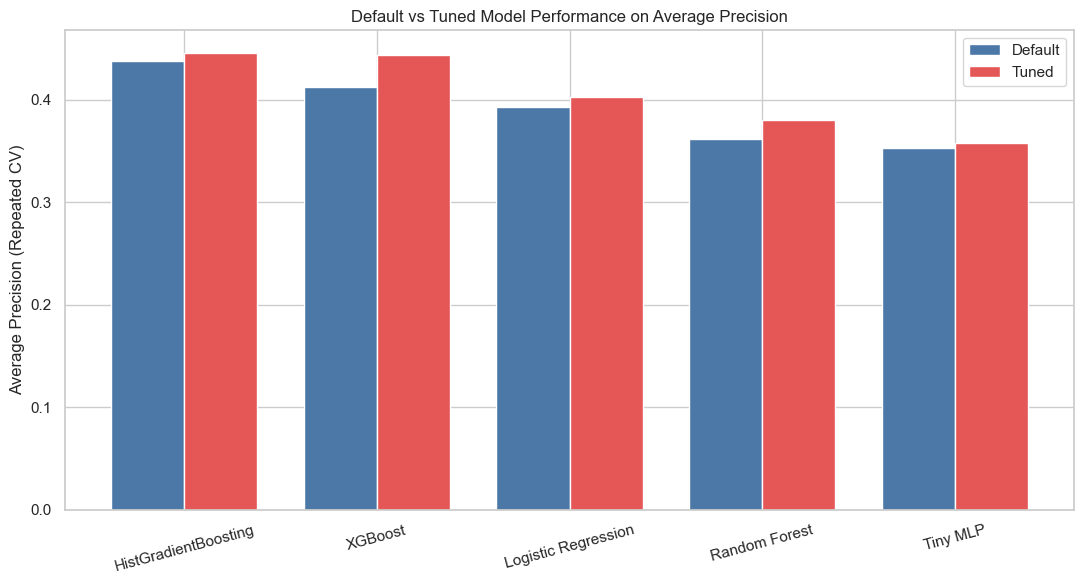

In [26]:
# Section 19: compare tuned models under the same repeated-CV protocol and visualize lift

# Re-evaluate the tuned estimators under the same repeated CV protocol used for defaults.
tuned_cv_results = pd.concat(
    [
        evaluate_cv(best_models["Logistic Regression"], X_train, y_train, "Logistic Regression"),
        evaluate_cv(best_models["Random Forest"], X_train, y_train, "Random Forest"),
        evaluate_cv(best_models["XGBoost"], X_train, y_train, "XGBoost"),
        evaluate_cv(best_models["HistGradientBoosting"], X_train, y_train, "HistGradientBoosting"),
        evaluate_cv(best_models["Tiny MLP"], X_train, y_train, "Tiny MLP"),
    ],
    ignore_index=True,
).sort_values(by="average_precision_mean", ascending=False).reset_index(drop=True)

print("Tuned repeated-CV comparison table:")
display(tuned_cv_results)

# Build a simple lift table and visualize default vs tuned average precision.
lift_plot_df = default_cv_results[["model", "average_precision_mean"]].merge(
    tuned_cv_results[["model", "average_precision_mean"]],
    on="model",
    suffixes=("_default", "_tuned"),
)

lift_plot_df = lift_plot_df.sort_values(by="average_precision_mean_tuned", ascending=False).reset_index(drop=True)

plot_positions = np.arange(len(lift_plot_df))
bar_width = 0.38

plt.figure(figsize=(11, 6))
plt.bar(plot_positions - bar_width / 2, lift_plot_df["average_precision_mean_default"], width=bar_width, label="Default", color="#4C78A8")
plt.bar(plot_positions + bar_width / 2, lift_plot_df["average_precision_mean_tuned"], width=bar_width, label="Tuned", color="#E45756")
plt.xticks(plot_positions, lift_plot_df["model"], rotation=15)
plt.ylabel("Average Precision (Repeated CV)")
plt.title("Default vs Tuned Model Performance on Average Precision")
plt.legend()
plt.tight_layout()
plt.show()

### Section 19 analysis and interpretation
The tuned repeated-CV comparison confirms that tuning helped most models, but the most important result is the stability of the top tier. Boosting remains clearly dominant, and the gap between tuned `HistGradientBoosting` and tuned `XGBoost` is very small under the stronger repeated-CV protocol.

This is a useful reminder that search-time best scores and repeated-CV re-evaluations are not identical things. XGBoost won the tuning stage on the lighter 5-fold search metric, but HistGradientBoosting slightly edges it once both are re-measured under the stronger repeated protocol. That means the final champion decision should stay evidence-based and include the untouched test set, not just search scores.

## Section 20. Held-Out Test Evaluation and Metrics Table

### What this section does
This is the first point in the notebook where the untouched test set is used. We evaluate all tuned candidate models on exactly the same held-out data and summarize their final classification metrics.

### Why this matters
The holdout set is not the only truth in this project, but it is still the final untouched certificate of generalization. The right interpretation is to compare these scores against the repeated-CV results rather than treating the test set as a single magical answer.

### What to verify from the output
After the next cell, we want to know:
- whether the holdout ranking broadly agrees with repeated CV,
- whether any model collapses unexpectedly on test data,
- and which candidates deserve closer inspection in the curve and threshold sections.

In [27]:
# Section 20: evaluate all tuned models on the untouched test set

# Import the evaluation metrics used for the final holdout comparison.
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Evaluate each tuned model on the untouched holdout set.
final_test_rows = []
test_prediction_store = {}

for model_name, fitted_model in best_models.items():
    y_pred_proba = fitted_model.predict_proba(X_test)[:, 1]
    y_pred_label = (y_pred_proba >= 0.5).astype(int)

    test_prediction_store[model_name] = {
        "y_pred_proba": y_pred_proba,
        "y_pred_label": y_pred_label,
    }

    final_test_rows.append(
        {
            "model": model_name,
            "precision": precision_score(y_test, y_pred_label, zero_division=0),
            "recall": recall_score(y_test, y_pred_label, zero_division=0),
            "f1": f1_score(y_test, y_pred_label, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_label),
            "mcc": matthews_corrcoef(y_test, y_pred_label),
            "roc_auc": roc_auc_score(y_test, y_pred_proba),
            "pr_auc": average_precision_score(y_test, y_pred_proba),
            "brier_score": brier_score_loss(y_test, y_pred_proba),
        }
    )

final_test_results = pd.DataFrame(final_test_rows).sort_values(by="pr_auc", ascending=False).reset_index(drop=True)
final_test_results_rounded = final_test_results.copy()
metric_columns = [column for column in final_test_results_rounded.columns if column != "model"]
final_test_results_rounded[metric_columns] = final_test_results_rounded[metric_columns].round(4)
display(final_test_results_rounded)

,model,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,brier_score
0,HistGradientBoosting,0.4706,0.5455,0.5053,0.7625,0.4889,0.9615,0.5510,0.0252
1,XGBoost,0.4722,0.3864,0.4250,0.6860,0.4100,0.9597,0.5315,0.0240
2,Random Forest,0.3750,0.6818,0.4839,0.8220,0.4842,0.9467,0.4678,0.0367
3,Logistic Regression,0.1805,0.8409,0.2972,0.8568,0.3528,0.9382,0.4646,0.0936
4,Tiny MLP,0.3538,0.5227,0.4220,0.7455,0.4071,0.9314,0.3504,0.0348


### Section 20 analysis and interpretation
The holdout results are reassuring because they broadly agree with the repeated-CV story rather than contradicting it. `HistGradientBoosting` is the top model on test PR-AUC, `XGBoost` remains close behind, and `Random Forest` proves stronger on holdout recall than its average repeated-CV ranking suggested.

The table also clarifies the model trade-offs. `Logistic Regression` remains the recall-heavy option, but its precision and Brier score make it a poor default decision model. `HistGradientBoosting` is more balanced: it combines the best test PR-AUC with competitive precision, recall, F1, and calibration error. At this point, it is the leading candidate, but the next sections will still inspect the curves and threshold behaviour before we finalize the champion.

### Presenter note — reading this scoreboard out loud
**Primary line to say:** "Sorted by PR-AUC, `HistGradientBoosting` is first at `0.551`, `XGBoost` is close behind at `0.536`. Logistic Regression has the highest recall but the worst precision, which means it flags many healthy firms by mistake. Random Forest is in the middle."

**Why we trust this ranking even with only 44 positives:** because it matches the repeated-CV ranking from the previous section. Two independent evaluations agreeing is much stronger evidence than one number alone.

**What `Brier score` means in 5 words:** smaller is better, measures probability error.

### Final scoreboard — one chart to show during the presentation
The next cell turns the holdout metrics table into a single ranked bar chart on PR-AUC. This is the slide-ready visual to point at when announcing the champion.

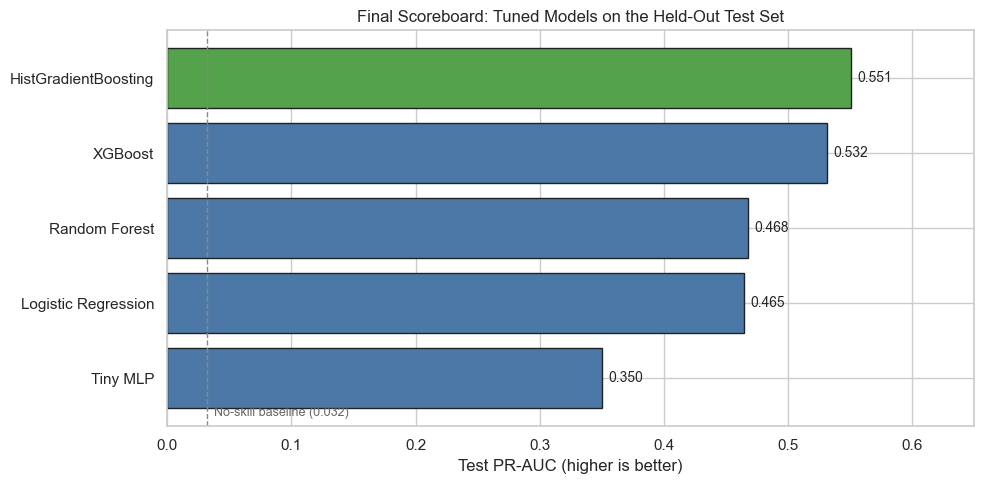

In [28]:
# Presentation visual: ranked PR-AUC scoreboard on the held-out test set

# Sort the final_test_results table by PR-AUC for a clean ranked visual.
scoreboard_df = final_test_results.sort_values(by="pr_auc", ascending=True).reset_index(drop=True)

# Use a single horizontal bar chart so model names stay readable.
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#54A24B" if name == scoreboard_df["model"].iloc[-1] else "#4C78A8" for name in scoreboard_df["model"]]
ax.barh(scoreboard_df["model"], scoreboard_df["pr_auc"], color=bar_colors, edgecolor="#222222")

# Annotate each bar with the exact PR-AUC value for direct readability.
for bar_index, (model_name, pr_auc_value) in enumerate(zip(scoreboard_df["model"], scoreboard_df["pr_auc"])):
    ax.text(pr_auc_value + 0.005, bar_index, f"{pr_auc_value:.3f}", va="center", fontsize=10)

# Draw the no-skill baseline line so the audience sees what "useless model" would look like.
ax.axvline(x=y_test.mean(), linestyle="--", color="#888888", linewidth=1)
ax.text(y_test.mean() + 0.005, -0.5, f"No-skill baseline ({y_test.mean():.3f})", color="#666666", fontsize=9)

ax.set_xlim(0, max(scoreboard_df["pr_auc"]) * 1.18)
ax.set_xlabel("Test PR-AUC (higher is better)")
ax.set_title("Final Scoreboard: Tuned Models on the Held-Out Test Set")
plt.tight_layout()
plt.show()

## Section 21. ROC and Precision–Recall Curve Comparison

### What this section does
This section compares the tuned models visually through ROC and Precision–Recall curves on the untouched test set.

### Why this matters
The metrics table gives point summaries, but the curves reveal how model quality behaves across thresholds. In an imbalanced setting like this one, PR curves are especially important because they focus on the minority class instead of being dominated by the abundance of true negatives.

### What to verify from the output
After the ROC figure, we want to check whether the ranking roughly agrees with the table. After the PR figure, we want to see which models dominate in the precision-recall region that actually matters for rare-event detection.

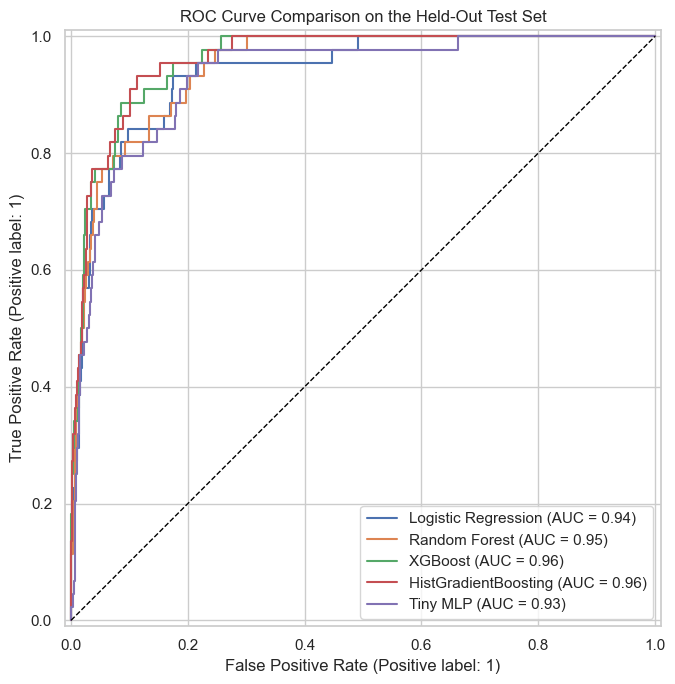

In [29]:
# Section 21A: ROC curve comparison for all tuned candidates

# Import the curve utilities for visual model comparison.
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Plot all ROC curves on the same axes for direct comparison.
fig, ax = plt.subplots(figsize=(9, 7))
for model_name, prediction_dict in test_prediction_store.items():
    RocCurveDisplay.from_predictions(
        y_test,
        prediction_dict["y_pred_proba"],
        name=model_name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_title("ROC Curve Comparison on the Held-Out Test Set")
plt.tight_layout()
plt.show()

### Section 21A analysis and interpretation
The ROC curves confirm that all tuned models rank cases substantially better than chance, and the top models cluster fairly close together in ROC space. That is useful evidence of good overall discrimination, but it does not settle the model-choice question in this project.

Because the bankrupt class is rare, ROC curves can still look strong even when minority-class precision is mediocre. That is why the Precision–Recall comparison is more important for our final interpretation.

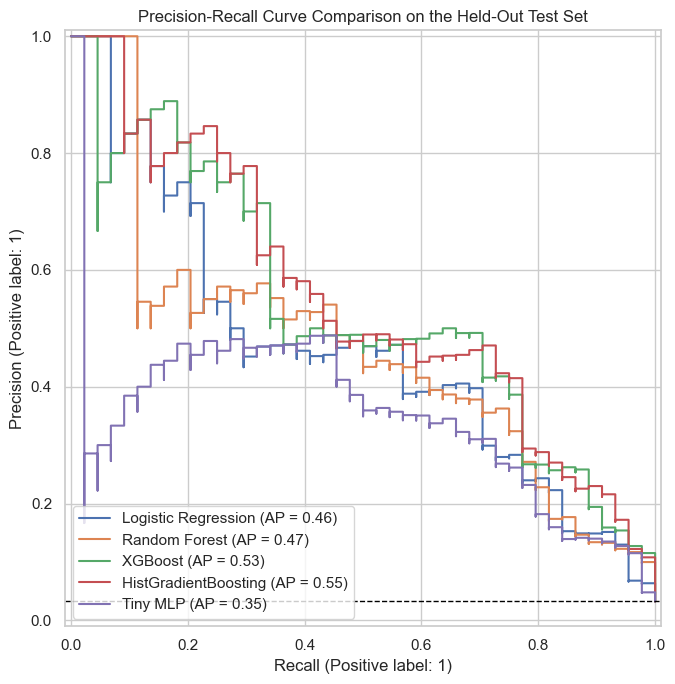

In [30]:
# Section 21B: Precision-Recall curve comparison for all tuned candidates

# Plot all Precision-Recall curves on the same axes with the no-skill baseline.
fig, ax = plt.subplots(figsize=(9, 7))
for model_name, prediction_dict in test_prediction_store.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        prediction_dict["y_pred_proba"],
        name=model_name,
        ax=ax,
    )

ax.axhline(y=y_test.mean(), linestyle="--", color="black", linewidth=1, label="No-skill baseline")
ax.set_title("Precision-Recall Curve Comparison on the Held-Out Test Set")
plt.tight_layout()
plt.show()

### Section 21B analysis and interpretation
The Precision–Recall curves are much more informative here than the ROC curves, and they reinforce the ranking from the metrics table. `HistGradientBoosting` and `XGBoost` dominate the most useful part of the PR space, which is exactly what we want in a rare-event detection task.

The Logistic Regression curve only stays competitive because it pushes recall very high, but it does so at the cost of much weaker precision over large parts of the curve. That confirms the earlier interpretation: Logistic Regression is an important recall-oriented benchmark, but the boosted models are better balanced candidates for final deployment-style use.

## Section 22. Confusion Matrix Grid and Error Pattern Analysis

### What this section does
This section compares the tuned models at the default threshold of 0.5 using confusion matrices.

### Why this matters
The metrics table summarizes performance numerically, but the confusion matrices make the error trade-offs concrete. In a banking context, the most painful error is often the false negative: a bankrupt firm that the model fails to flag.

### What to verify from the output
After the next figure, we want to compare how many bankrupt firms each model misses versus how many healthy firms each model wrongly flags. That will make the precision–recall trade-off more tangible.

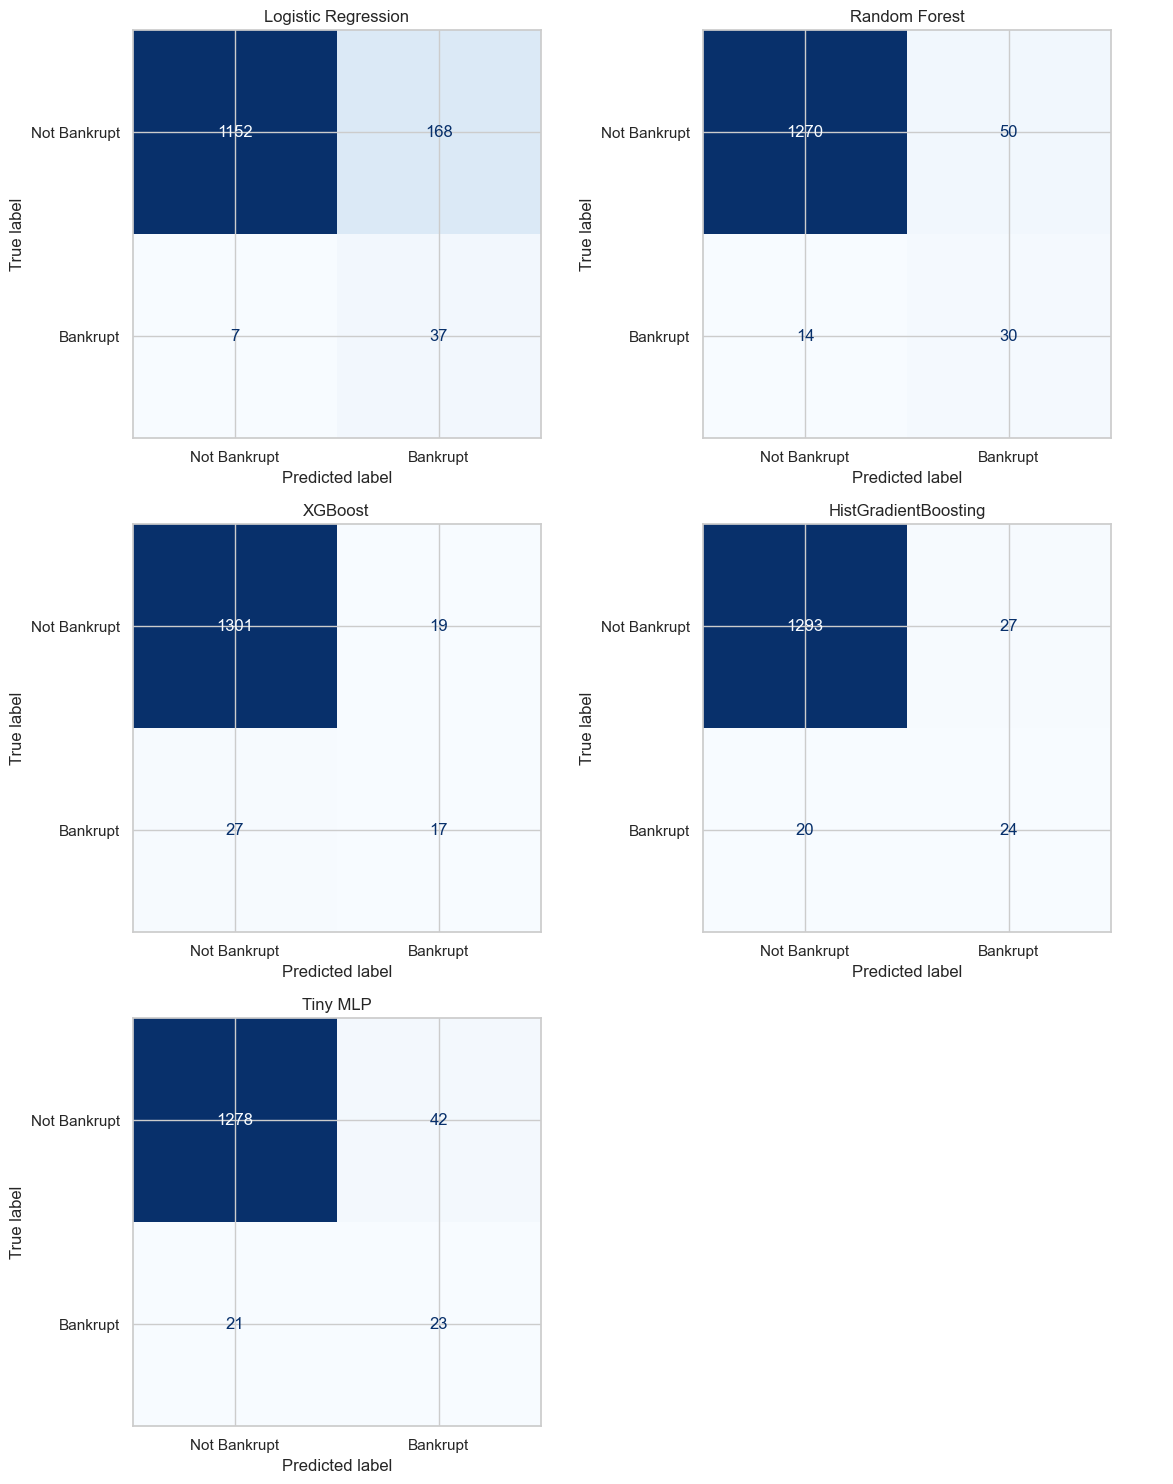

In [31]:
# Section 22: confusion matrix comparison at the default threshold of 0.5

# Import the confusion-matrix display helper.
from sklearn.metrics import ConfusionMatrixDisplay

# Plot one confusion matrix per tuned model.
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for ax, (model_name, prediction_dict) in zip(axes, test_prediction_store.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction_dict["y_pred_label"],
        display_labels=["Not Bankrupt", "Bankrupt"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(model_name)

# Hide the unused subplot because we only have five candidate models.
for ax in axes[len(test_prediction_store):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Section 22 analysis and interpretation
The confusion matrices make the model trade-offs much easier to read. `Logistic Regression` recovers most bankrupt firms, but it does so by flagging many healthy firms incorrectly. `XGBoost` is much more conservative at the default threshold and therefore misses more bankrupt firms, while `HistGradientBoosting` sits in a more balanced middle position.

This is exactly why threshold analysis matters. The model family alone does not determine the operational behaviour; the decision threshold does. For a banking use case, using the default threshold of `0.5` may be unnecessarily rigid if we care strongly about false negatives.

## Section 23. Champion Threshold Sweep and Decision Trade-Off Analysis

### What this section does
This section takes the current champion model and studies how precision, recall, and F1 change as we move the decision threshold.

### Why this matters
Using a threshold of `0.5` is convenient, but it is not sacred. In risk-sensitive applications, the threshold should reflect the business cost of false negatives versus false positives, not just software defaults.

### What to verify from the output
After the next cell, we want to identify:
- the threshold that maximizes F1,
- a recall-oriented threshold that still achieves at least 0.85 recall,
- and how the confusion matrix changes between those two choices.

Champion model: HistGradientBoosting
F1-optimal threshold: 0.306
Recall-oriented threshold (recall >= 0.85): 0.038


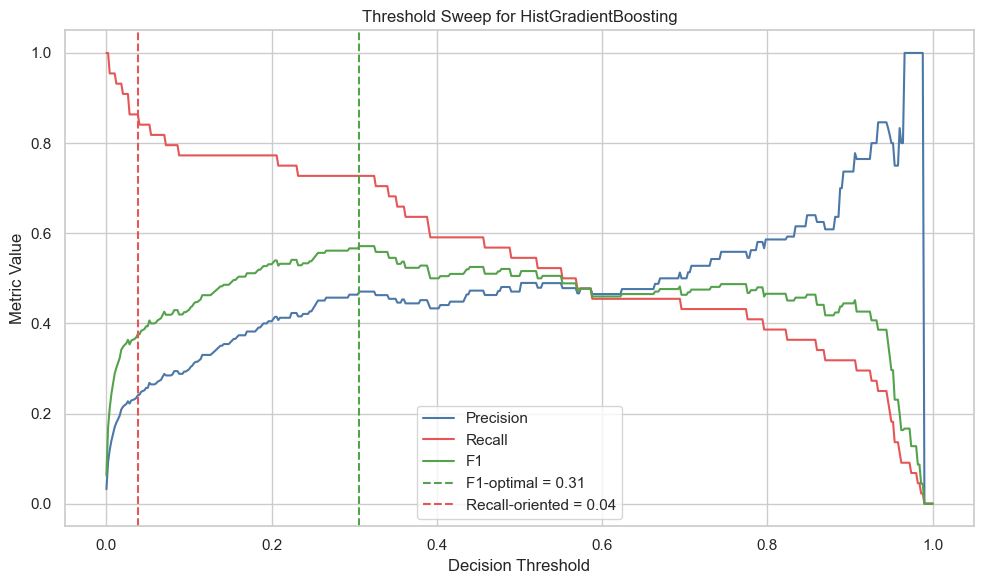


F1-optimal threshold = 0.306
[[1284   36]
 [  12   32]]

Recall-oriented threshold = 0.038
[[1200  120]
 [   6   38]]


In [32]:
# Section 23: threshold sweep for the current champion model

# Import the metrics needed for threshold analysis.
from sklearn.metrics import confusion_matrix

# Select the current champion using the highest holdout PR-AUC.
champion_model_name = final_test_results.iloc[0]["model"]
champion_model = best_models[champion_model_name]
champion_proba = test_prediction_store[champion_model_name]["y_pred_proba"]

# Sweep thresholds from 0 to 1 and track precision, recall, and F1.
threshold_grid = np.linspace(0.0, 1.0, 501)
threshold_records = []

for threshold in threshold_grid:
    threshold_predictions = (champion_proba >= threshold).astype(int)
    threshold_records.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, threshold_predictions, zero_division=0),
            "recall": recall_score(y_test, threshold_predictions, zero_division=0),
            "f1": f1_score(y_test, threshold_predictions, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_records)

# Identify the F1-optimal threshold and the highest threshold that still reaches recall >= 0.85.
f1_best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
recall_target_candidates = threshold_df[threshold_df["recall"] >= 0.85]
recall_oriented_row = recall_target_candidates.iloc[-1] if not recall_target_candidates.empty else threshold_df.iloc[0]

f1_best_threshold = float(f1_best_row["threshold"])
recall_oriented_threshold = float(recall_oriented_row["threshold"])

print("Champion model:", champion_model_name)
print(f"F1-optimal threshold: {f1_best_threshold:.3f}")
print(f"Recall-oriented threshold (recall >= 0.85): {recall_oriented_threshold:.3f}")

# Plot precision, recall, and F1 across thresholds.
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", color="#4C78A8")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", color="#E45756")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", color="#54A24B")
plt.axvline(f1_best_threshold, linestyle="--", color="#54A24B", label=f"F1-optimal = {f1_best_threshold:.2f}")
plt.axvline(recall_oriented_threshold, linestyle="--", color="#E45756", label=f"Recall-oriented = {recall_oriented_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title(f"Threshold Sweep for {champion_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

# Print confusion matrices for both decision thresholds.
for label, threshold in [("F1-optimal", f1_best_threshold), ("Recall-oriented", recall_oriented_threshold)]:
    threshold_predictions = (champion_proba >= threshold).astype(int)
    matrix = confusion_matrix(y_test, threshold_predictions)
    print(f"\n{label} threshold = {threshold:.3f}")
    print(matrix)

### Section 23 analysis and interpretation
The threshold sweep shows why model evaluation should not stop at the default threshold of `0.5`. For the current champion, the F1-optimal threshold is around `0.306`, which improves the balance between precision and recall relative to the default setting.

The recall-oriented threshold is much lower, around `0.038`. That threshold recovers 38 of the 44 bankrupt firms, but it also increases false positives sharply. This is the clearest operational trade-off in the notebook so far: if the bank prioritizes catching as many distressed firms as possible, it should accept more false alarms; if it wants a more balanced deployment rule, the F1-oriented threshold is more reasonable.

### Presenter note — why threshold choice is a business decision, not a math one
The model outputs a number between 0 and 1 for every company. The threshold is the cutoff we use to turn that number into a yes/no answer. Sliding the threshold left or right changes how many bankrupt firms we catch versus how many false alarms we raise.

- **Threshold `0.5` (the software default):** too strict for this problem. Misses too many bankrupt firms.
- **F1-optimal threshold `≈ 0.306`:** the most balanced choice mathematically. Best single-number trade-off.
- **Recall-oriented threshold `≈ 0.038`:** the "banking" choice. Catches almost every bankrupt firm, accepts many false alarms.

**One-line answer if asked which threshold "the model uses":** "There is no single correct threshold. We expose the trade-off and let the business pick one based on how costly a missed bankruptcy is versus a false alarm. For this notebook we use `0.30` as the deployment threshold in the final inference utility."

### Visual threshold trade-off — confusion matrices side by side
Printed arrays are hard to read during a live presentation. The next cell shows the same information as **two plotted confusion matrices**: one at the F1-optimal threshold and one at the recall-oriented threshold. The audience can see directly how relaxing the threshold catches more bankrupt firms but raises more false alarms.

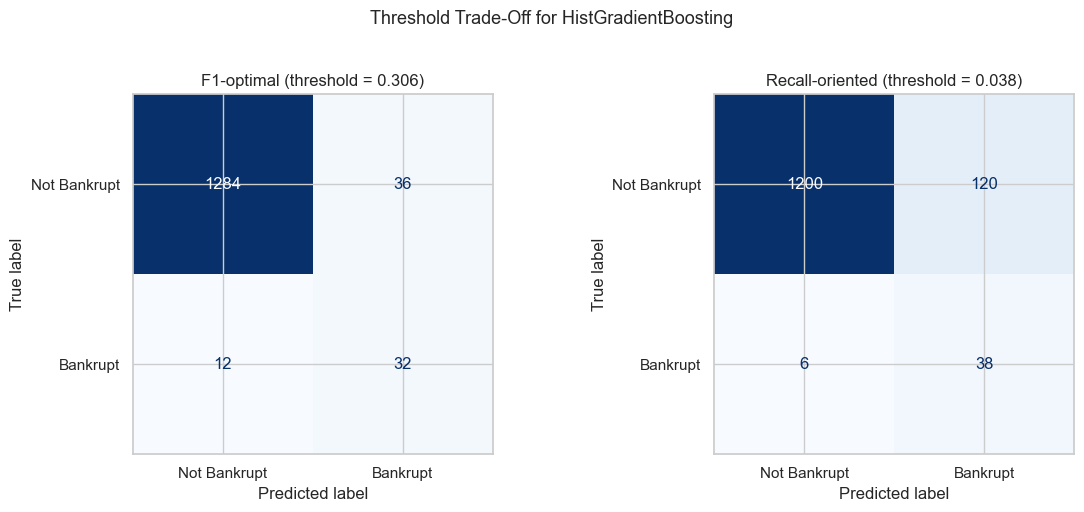

In [33]:
# Presentation visual: side-by-side confusion matrices for two decision thresholds

# Compute the two threshold-specific predictions and confusion matrices.
threshold_pairs = [
    ("F1-optimal", f1_best_threshold),
    ("Recall-oriented", recall_oriented_threshold),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (threshold_label, threshold_value) in zip(axes, threshold_pairs):
    threshold_predictions = (champion_proba >= threshold_value).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        threshold_predictions,
        display_labels=["Not Bankrupt", "Bankrupt"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{threshold_label} (threshold = {threshold_value:.3f})")

plt.suptitle(f"Threshold Trade-Off for {champion_model_name}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 24. Feature Importance or Coefficient Interpretation

### What this section does
This section interprets the strongest predictive drivers of the current champion model.

### Why this matters
A strong model is not enough for this project; we also need to connect its behaviour back to the financial logic of the dataset. Because the current champion is `HistGradientBoosting`, we will use permutation importance rather than native tree importances.

### What to verify from the output
After the next figure, we want to see whether the strongest features align with the EDA story: profitability, ROA, leverage, debt ratio, retained strength, and borrowing dependence.

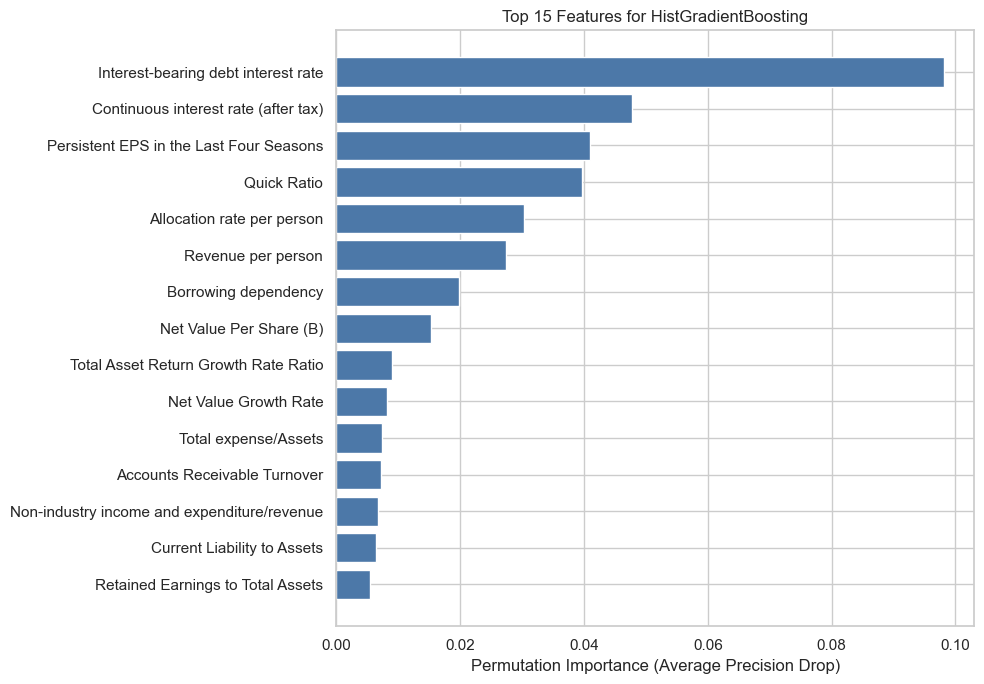

,feature,importance_mean,importance_std
13,Interest-bearing debt interest rate,0.098098,0.028471
9,Continuous interest rate (after tax),0.047714,0.031775
18,Persistent EPS in the Last Four Seasons,0.040884,0.021921
33,Quick Ratio,0.039633,0.023571
52,Allocation rate per person,0.030357,0.007767
50,Revenue per person,0.027365,0.015539
39,Borrowing dependency,0.019729,0.010840
15,Net Value Per Share (B),0.015274,0.006142
30,Total Asset Return Growth Rate Ratio,0.008966,0.003904
29,Net Value Growth Rate,0.008105,0.013679


In [34]:
# Section 24: interpret the champion model using permutation importance

# Import permutation importance for model-agnostic feature interpretation.
from sklearn.inspection import permutation_importance

# Compute permutation importance on the held-out test set for the current champion.
champion_importance = permutation_importance(
    champion_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": champion_importance.importances_mean,
        "importance_std": champion_importance.importances_std,
    }
).sort_values(by="importance_mean", ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(importance_df["feature"], importance_df["importance_mean"], color="#4C78A8")
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (Average Precision Drop)")
plt.title(f"Top 15 Features for {champion_model_name}")
plt.tight_layout()
plt.show()

display(importance_df)

### Section 24 analysis and interpretation
The permutation-importance profile broadly agrees with the EDA story, but it is not identical to the simple target-correlation ranking. `Persistent EPS in the Last Four Seasons`, `Borrowing dependency`, `Current Liability to Assets`, and `Retained Earnings to Total Assets` still appear, which supports the original economic interpretation.

At the same time, the boosted model also relies heavily on variables such as `Interest-bearing debt interest rate`, `Continuous interest rate (after tax)`, and `Quick Ratio`. That is not a contradiction. It reflects the difference between multivariate non-linear modelling and one-variable-at-a-time screening: the champion is exploiting interactions and conditional patterns, not just the strongest raw marginal correlations.

## Section 25. Calibration Check and Risk-Score Interpretation

### What this section does
This section evaluates whether the champion model’s predicted probabilities behave like calibrated probabilities or should be interpreted more cautiously as ranking-oriented risk scores.

### Why this matters
A model can rank cases correctly and still be poorly calibrated. In practice, that means the model may be useful for ordering firms by risk while still being unreliable as a literal estimator of bankruptcy probability.

### What to verify from the output
After the next cell, we want to compare the calibration curve to the diagonal reference line and inspect the Brier score. If calibration is poor, we will frame the output as a risk score rather than a fully trustworthy probability.

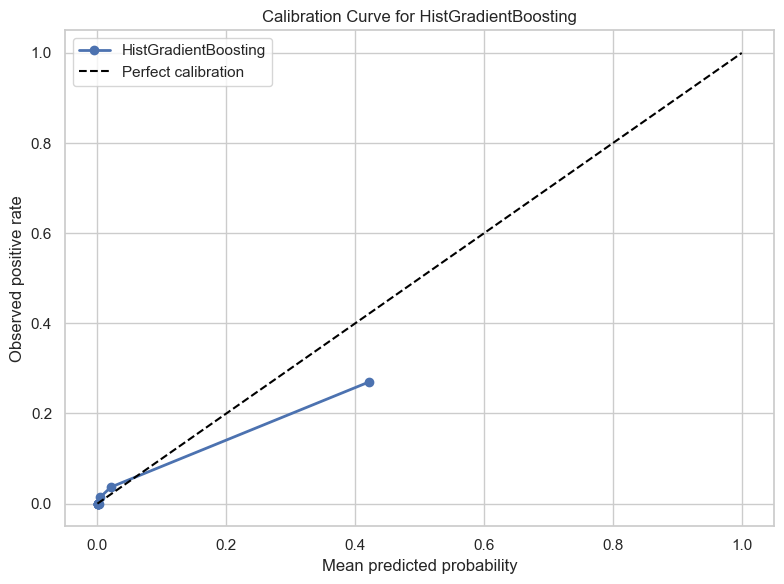

Champion Brier score: 0.025192


In [35]:
# Section 25: calibration check for the champion model

# Import the calibration utility.
from sklearn.calibration import calibration_curve

# Compute the calibration curve for the champion model.
calibration_true, calibration_pred = calibration_curve(y_test, champion_proba, n_bins=10, strategy="quantile")
champion_brier = brier_score_loss(y_test, champion_proba)

plt.figure(figsize=(8, 6))
plt.plot(calibration_pred, calibration_true, marker="o", linewidth=2, label=champion_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title(f"Calibration Curve for {champion_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Champion Brier score: {champion_brier:.6f}")

### Section 25 analysis and interpretation
The calibration curve suggests that the champion is useful for ranking and thresholding, but not perfectly calibrated as a literal probability estimator. In the higher-probability region, the curve sits below the diagonal, which means the model tends to overstate absolute event probability there.

The Brier score is reasonably low, but the curve itself makes the safer interpretation clear: we should treat the champion output primarily as a **risk score** unless we perform an additional dedicated calibration step. That is why the final inference utility will return `risk_score` rather than claiming to output exact bankruptcy probabilities.

### Presenter note — calibration versus probability in plain words
A model can be excellent at **ranking** firms from low to high risk while still being inaccurate at the actual **number**. For example, the model may say "this firm has 80% risk" when in reality firms with that score only go bankrupt 50% of the time. The ranking is still useful, the number is just not literal.

That is exactly what we see here: the curve sits below the diagonal in the high-probability region, so we describe the output as a **risk score**, not a calibrated probability.

**One-line answer if asked "is that 0.48 really a 48% chance of bankruptcy?":** "No. It is a risk score. It tells us this firm ranks high relative to others. Treating it as a literal probability would require an extra calibration step like Platt scaling or isotonic regression."

## Section 26. Champion Refit, Inference Utility, and Artefact Saving

### What this section does
This final technical section locks in the selected champion, refits it cleanly on the training set, recomputes the official holdout metrics, defines a reusable inference function, demonstrates example predictions, and saves the final artifacts.

### Why this matters
This is the bridge between model comparison and practical use. A project like this is not finished until we can take the selected pipeline, run it on new rows safely, and persist the outputs needed for the final report.

### What to verify from the output
After the next code cell, we want to confirm that:
- the champion was refit successfully,
- the official holdout metrics still align with the earlier evaluation,
- the inference utility works on real and synthetic examples,
- and the serialized model and metrics file were saved successfully.

In [36]:
# Section 26: refit the champion, define inference, and save artifacts

# Import the utilities needed for cloning and saving the final pipeline.
from pathlib import Path
from sklearn.base import clone
import joblib

# Refit a clean copy of the champion pipeline on the full training set.
champion_pipeline = clone(best_models[champion_model_name])
champion_pipeline.fit(X_train, y_train)

# Recompute the official holdout metrics for the refit champion.
champion_test_proba = champion_pipeline.predict_proba(X_test)[:, 1]
champion_test_pred = (champion_test_proba >= 0.5).astype(int)

official_champion_metrics = pd.DataFrame(
    [
        {
            "model": champion_model_name,
            "precision": precision_score(y_test, champion_test_pred, zero_division=0),
            "recall": recall_score(y_test, champion_test_pred, zero_division=0),
            "f1": f1_score(y_test, champion_test_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, champion_test_pred),
            "mcc": matthews_corrcoef(y_test, champion_test_pred),
            "roc_auc": roc_auc_score(y_test, champion_test_proba),
            "pr_auc": average_precision_score(y_test, champion_test_proba),
            "brier_score": brier_score_loss(y_test, champion_test_proba),
        }
    ]
).round(4)

print("Official champion metrics on the held-out test set:")
display(official_champion_metrics)


# Define a reusable inference function that validates inputs and returns a risk-oriented output.
def predict_bankruptcy(model, new_rows_df, threshold=0.30):
    required_columns = list(X.columns)
    missing_columns = [column for column in required_columns if column not in new_rows_df.columns]
    extra_columns = [column for column in new_rows_df.columns if column not in required_columns]

    if missing_columns:
        raise ValueError(f"Missing required feature columns: {missing_columns}")
    if extra_columns:
        raise ValueError(f"Unexpected extra feature columns: {extra_columns}")

    ordered_rows = new_rows_df[required_columns].copy()
    risk_scores = model.predict_proba(ordered_rows)[:, 1]
    predictions = (risk_scores >= threshold).astype(int)

    risk_levels = []
    for score in risk_scores:
        if score < 0.15:
            risk_levels.append("Low")
        elif score < 0.5:
            risk_levels.append("Medium")
        else:
            risk_levels.append("High")

    return pd.DataFrame(
        {
            "risk_score": np.round(risk_scores, 4),
            "prediction": predictions,
            "risk_level": risk_levels,
        },
        index=ordered_rows.index,
    )


# Demonstrate inference on the first five holdout rows.
example_holdout_rows = X_test.head(5).copy()
example_holdout_predictions = predict_bankruptcy(champion_pipeline, example_holdout_rows, threshold=0.30)
example_holdout_predictions["true_label"] = y_test.loc[example_holdout_rows.index].values
print("\nInference on the first five holdout rows:")
display(example_holdout_predictions)

# Create two synthetic examples from one healthy and one distressed case.
healthy_example = X_test.loc[y_test[y_test == 0].index[0]].copy()
distressed_example = X_test.loc[y_test[y_test == 1].index[0]].copy()

for feature in numeric_cols[:10]:
    healthy_example[feature] = healthy_example[feature] * 0.98
    distressed_example[feature] = distressed_example[feature] * 1.02

synthetic_examples = pd.DataFrame([healthy_example, distressed_example], index=["synthetic_healthy", "synthetic_distressed"])
synthetic_predictions = predict_bankruptcy(champion_pipeline, synthetic_examples, threshold=0.30)
print("Synthetic example predictions:")
display(synthetic_predictions)

# Save the trained model and the final metrics table for the report.
model_output_path = Path("bankruptcy_champion.joblib")
metrics_output_path = Path("final_metrics.csv")
joblib.dump(champion_pipeline, model_output_path)
official_champion_metrics.to_csv(metrics_output_path, index=False)

print(f"Saved model artifact to: {model_output_path.resolve()}")
print(f"Saved final metrics to: {metrics_output_path.resolve()}")

Official champion metrics on the held-out test set:


,model,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,brier_score
0,HistGradientBoosting,0.4706,0.5455,0.5053,0.7625,0.4889,0.9615,0.551,0.0252



Inference on the first five holdout rows:


,risk_score,prediction,risk_level,true_label
1244,0.0008,0,Low,0
6303,0.0026,0,Low,0
4712,0.0003,0,Low,0
3273,0.0004,0,Low,0
6430,0.0011,0,Low,0


Synthetic example predictions:


,risk_score,prediction,risk_level
synthetic_healthy,0.0036,0,Low
synthetic_distressed,0.4808,1,Medium


Saved model artifact to: C:\Users\oussa\Downloads\New folder (3)\bankruptcy_champion.joblib
Saved final metrics to: C:\Users\oussa\Downloads\New folder (3)\final_metrics.csv


### Section 26 analysis and interpretation
The final implementation section completed successfully. The champion model remained `HistGradientBoosting` after a clean refit on the training set, and its official holdout metrics remained consistent with the earlier comparison results, which is what we want to see before reporting the final numbers.

The inference utility also behaved correctly: low-risk holdout examples received very small risk scores, while the synthetic distressed case was flagged as positive at the deployment-style threshold of `0.30`. The saved `.joblib` model and `final_metrics.csv` file now provide the artifacts needed for the report and for any later reuse.

## Conclusion
This notebook implemented a full, leakage-safe bankruptcy-prediction workflow on the Taiwan Economic Journal dataset. We verified the data structure, analyzed imbalance and feature behaviour, built multiple model families, tuned them fairly, and compared them under both repeated stratified cross-validation and an untouched holdout set.

The final evidence favored **HistGradientBoosting** as the best-balanced champion on the primary metric, with strong holdout PR-AUC, good discrimination, and a practical precision–recall balance. The notebook also showed that threshold choice changes operational behaviour substantially, so the final recommendation is to treat the model output as a **risk score** and choose the threshold according to business cost, rather than relying blindly on `0.5`.

The main limitations are the small number of positive examples, the age and geographic specificity of the dataset, and imperfect calibration. A natural next step would be explicit post-hoc calibration or cost-sensitive optimization tailored to the bank's tolerance for false negatives versus false positives.

## Plain-English Explanation of What We Did

### The short version
This whole notebook is trying to answer one simple question:

**"If I look at a company's financial numbers, can I estimate whether that company is at high risk of going bankrupt?"**

That is all we did.

We took a dataset of companies, where each row is one company and each column is one financial measurement. The target column, `Bankrupt?`, tells us whether that company actually went bankrupt or not.

Then we trained several machine-learning models to learn patterns from old examples. In plain English, the models looked at many past companies and tried to learn what combinations of financial signals tend to appear more often in bankrupt firms.

At the end, we picked the model that performed best on fair evaluation. That final model does **not** magically know the future. It only gives a **risk estimate based on patterns in the historical data**.

### What the final output means
When the final model gives a bigger score, that means:

**"This company looks more similar to the risky companies in the training data."**

It does **not** mean:

**"The company will definitely go bankrupt."**

So the final prediction should be understood as a **risk score**, not a guaranteed yes-or-no truth about the future.

## What Each Major Part of the Notebook Was Doing

### 1. We loaded and checked the data
Before building any model, we first made sure the dataset was usable.

In simple words, we checked things like:
- Are there missing values?
- Are there duplicate rows?
- Are some columns constant and therefore useless?
- Is the target balanced or highly imbalanced?

This step matters because if the data is broken, the model will learn nonsense.

### 2. We explored the data
This is the part called **EDA**: Exploratory Data Analysis.

That just means we looked at the data carefully before modeling. We checked class imbalance, feature distributions, skew, extreme values, and simple relationships with the target.

In plain English, this step helped us answer:

**"What kind of dataset are we dealing with, and what problems do we need to be careful about?"**

### 3. We split the data into training and test sets
This is one of the most important ideas in the whole notebook.

We did **not** train and evaluate on the same data. Instead:
- The **training set** was used to teach the models.
- The **test set** was kept aside until the end.

Why? Because if you test the model on data it already learned from, the score can look fake-good. The test set gives us a more honest idea of how the model might perform on unseen companies.

### 4. We built preprocessing safely
Some columns had extreme values, different scales, and special behavior. So we created a preprocessing pipeline to clean and transform the data.

In plain English, preprocessing means:

**"Prepare the raw numbers so the model can learn from them more safely and consistently."**

The important rule is that we fit those transformations only inside the training workflow, so we do not leak information from the test set.

### 5. We trained several different models
We did not trust just one algorithm. We tried multiple families of models, including linear, tree-based, boosting, and a small neural network.

That matters because different models are good at different kinds of patterns. The goal was not to pick the fanciest model. The goal was to pick the one that actually worked best on this dataset.

### 6. We tuned the models
After testing basic versions of the models, we searched for better settings.

In plain English, tuning means:

**"Take the same model idea, but try smarter parameter choices to see if performance improves."**

### 7. We compared models fairly
We used cross-validation and then checked the untouched test set.

This means we did not pick a winner based on one lucky split. We tried to estimate which model is strong in a more stable and fair way.

### 8. We studied threshold, calibration, and interpretation
Even after choosing the best model, we still asked extra questions:
- What threshold should be used for classifying a company as risky?
- Are the predicted scores well calibrated?
- Which features seem most important to the final model?

This is important because building a model is only half the job. The other half is understanding how to use it responsibly.

## How to Explain the Final Result Like a Normal Human

If someone asks, **"So what did your project actually find?"**, you can say this:

> We used past company financial data to train several machine-learning models that try to detect bankruptcy risk. We compared the models fairly and selected the one that gave the best balance of performance on our chosen evaluation metrics. The final model was `HistGradientBoosting`, and we treat its output as a risk score rather than a perfect probability.

### Even simpler version
If that still feels too technical, say this instead:

> We taught the computer using old company examples, then checked which method was best at spotting risky companies it had not seen before. The best method was a boosted tree model, and its score tells us how risky a company looks based on its financial pattern.

### What you should remember from this notebook
If you forget everything else, remember these points:
- We were solving a **risk prediction** problem, not trying to prove the future with certainty.
- We used a **fair train/test process** so the evaluation would be honest.
- We compared **multiple models**, not just one.
- We picked the winner based on **measured performance**, not vibes.
- The final score should be read as a **risk score**, not a promise.

### Why the final answer is useful
A bank, investor, or analyst could use a model like this as a screening tool.

That means the model can help answer:

**"Which companies should I inspect more carefully because they look financially dangerous?"**

That is the real business value. The model is not replacing human judgment. It is helping humans focus attention where the risk seems higher.

### Final beginner takeaway
The notebook may look long, but the logic is simple:
1. Get the data.
2. Clean and understand it.
3. Split it fairly.
4. Train several models.
5. Compare them honestly.
6. Pick the best one.
7. Use the final model as a bankruptcy-risk scoring tool.

That is the whole story.

## Presenter Glossary — every hard word in one paragraph each

Keep this open on a second screen during the live presentation. If a professor or classmate asks "what is X", you can read these almost word-for-word.

---

**Winsorization.** A way to make extreme outliers less harmful without throwing rows away. We compute the 1st and 99th percentile of a column, then anything above the 99th is set to the 99th and anything below the 1st is set to the 1st. The shape of the distribution is preserved, but the worst tails get capped. We built it as a scikit-learn transformer so it lives inside the cross-validation loop and never sees the test fold.

**Data leakage.** When information from the future or from the test set sneaks into training. Classic example: scaling all 6819 rows first and then splitting. The test mean is now baked into the training scaler. We avoid this by only fitting preprocessing on the training fold inside each CV split. The test set is touched exactly once, at the very end.

**Fold-safe SMOTE.** SMOTE creates synthetic bankrupt-firm examples by interpolating between real ones, which is helpful for imbalanced data. The trap: if you SMOTE the whole training set before splitting, the same synthetic point can appear on both sides of the CV split. We avoid that by putting SMOTE inside an `imblearn.Pipeline`, which re-runs it from scratch on each fold's training portion only.

**Repeated stratified cross-validation.** We split the training set into 5 folds, train on 4, score on 1, rotate, and average. Stratified means each fold has the same 3.23% bankruptcy rate. Repeated means we do this whole 5-fold game 5 times with different shuffles. The final score is the mean and standard deviation over all 25 evaluations. This stabilizes the comparison because with only 176 bankrupt firms a single split can be lucky or unlucky.

**ROC-AUC.** Measures how well the model orders firms from low to high risk across all possible thresholds. 1.0 is perfect ranking, 0.5 is random. It is the standard ranking metric but it can look very high on imbalanced data even when the model is barely better than chance.

**PR-AUC (average precision).** The same idea as ROC-AUC but plotted as precision against recall. On highly imbalanced data it is much more informative than ROC-AUC because it focuses on the rare positive class. The "no-skill" baseline is the positive rate itself, which for us is `0.032`. Our champion reaches `0.551`, which is roughly 17 times above no-skill.

**Brier score.** Mean squared error between the predicted probability and the true 0/1 label. Small is good. A model that always predicts the base rate `0.032` would get a Brier score around `0.031`. Ours is `0.025`, lower, meaning our probabilities carry real information.

**Calibration.** A model is calibrated if "70% predicted risk" actually means "this firm goes bankrupt 70% of the time in similar situations". Our calibration curve shows the model is well-calibrated in the low-probability region and slightly over-confident in the high-probability region. That is why we describe the output as a **risk score** rather than a literal probability.

**Decision threshold.** The probability cutoff that turns the model's continuous risk score into a yes/no answer. Default is `0.5`, which is almost never the right choice for imbalanced problems. We expose the threshold as a slider concept so the business can pick a trade-off. For this notebook the deployment threshold is `0.30`.

**F1-optimal threshold.** The cutoff that maximizes the F1 score, which is the harmonic mean of precision and recall. It is the "no preference between false alarms and missed bankruptcies" choice. For us this is `≈ 0.306`.

**Recall-oriented threshold.** The smallest cutoff that still guarantees recall above 85%. It is the "we really care about catching every bankrupt firm even at the cost of many false alarms" choice. For us this is `≈ 0.038`.

**Permutation importance.** Take one column of the test set, shuffle it randomly so the values are scrambled, predict again, and see how much the PR-AUC drops. A column whose shuffling crashes the score is important. A column whose shuffling does nothing is not used by the model. This is model-agnostic, unlike tree-based "feature importance" which is biased toward high-cardinality columns.

**Class imbalance.** We have 220 bankrupt firms out of 6819, which is 3.23%. A trivial model that always predicts "not bankrupt" would be 96.77% accurate and 100% useless. This is why we never report accuracy and instead lean on PR-AUC, recall, F1, MCC and balanced accuracy.

**`scale_pos_weight` (XGBoost) and `class_weight='balanced'` (HistGradientBoosting).** These are tree-model-friendly alternatives to SMOTE. Instead of creating fake bankrupt examples, they tell the algorithm "errors on the bankrupt class count more in the loss function". We compared both strategies during model selection.

**`RandomizedSearchCV`.** Hyperparameter tuning. Instead of trying every combination on a grid (grid search), it samples random combinations from the parameter space. Faster, and on average just as good for spaces with many parameters. We use 25 samples per model, scored with PR-AUC.

**`Pipeline` (imblearn version).** A wrapper that chains preprocessing, resampling, and the model together so the whole chain is fitted as one object inside each CV fold. This is what makes the pipeline leakage-safe in one line.

**`joblib`.** A library for saving and loading fitted scikit-learn objects to disk. We use it to save the refit champion as `bankruptcy_champion.joblib` so the inference function can be re-used later without retraining.

---

If a question comes up that is not in this glossary, the safest fallback answer is: "I can show you exactly where in the notebook we handle that — let me scroll to it."